## 能带与费米面

Plotting Fig. 3 TB results from saved data
Saved figure: La3Ni2O7_film_Fig3_TB/figures/fig3a_TB_band_structure_orbital_weight.png


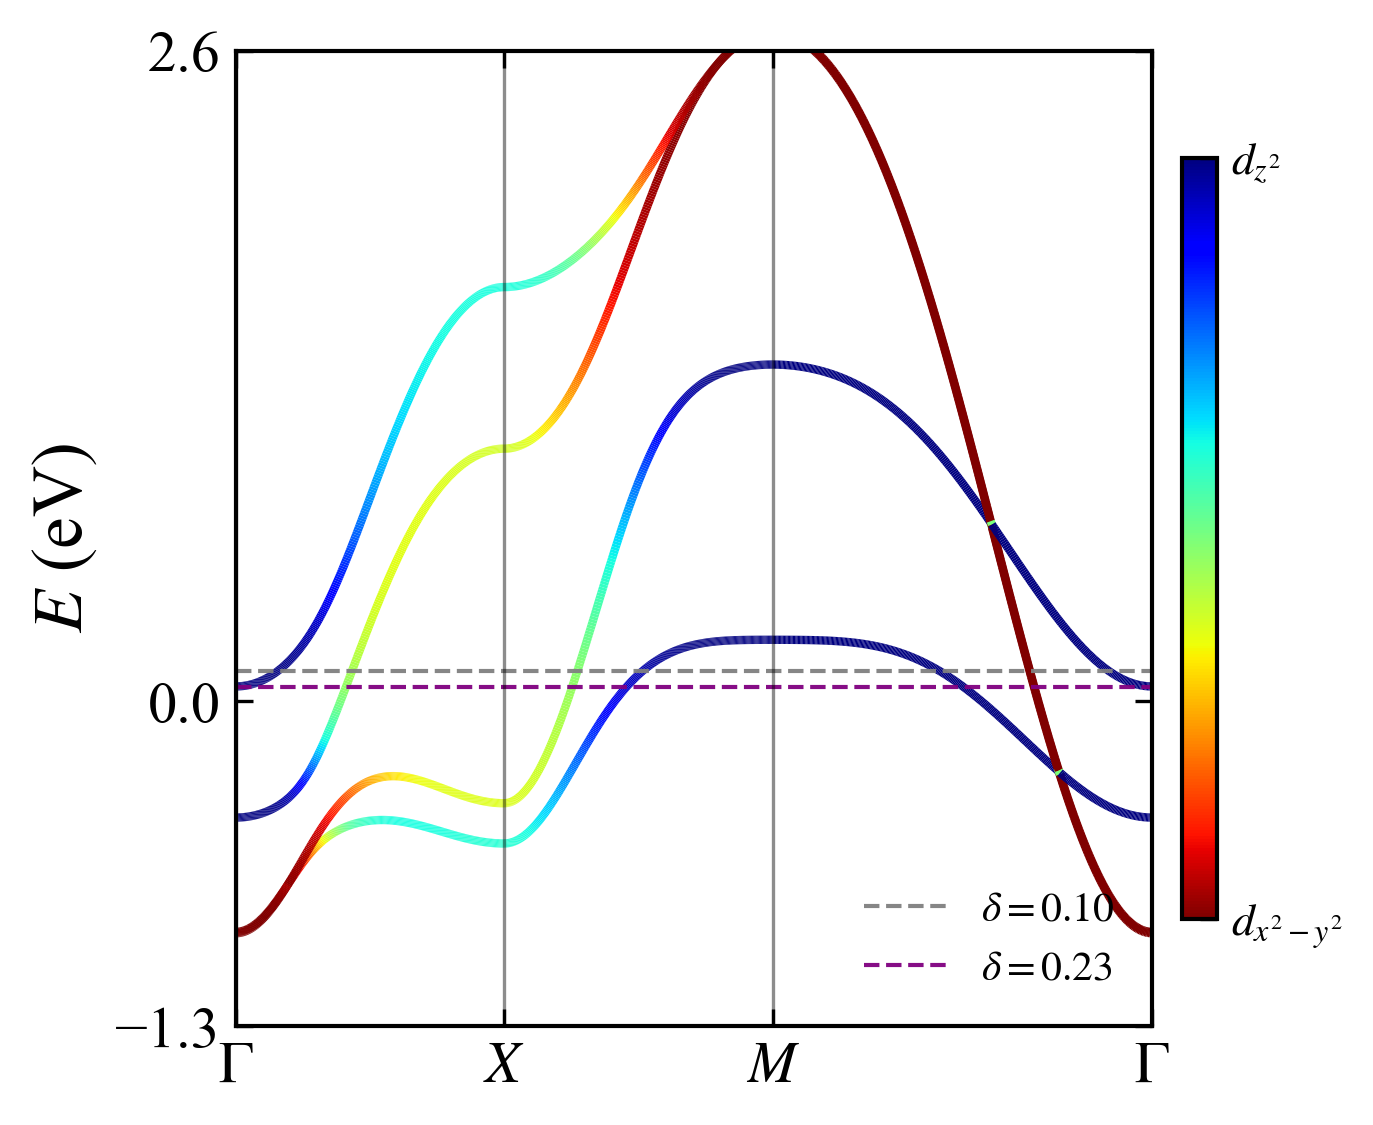

Saved figure: La3Ni2O7_film_Fig3_TB/figures/fig3_FS_delta_0p10.png


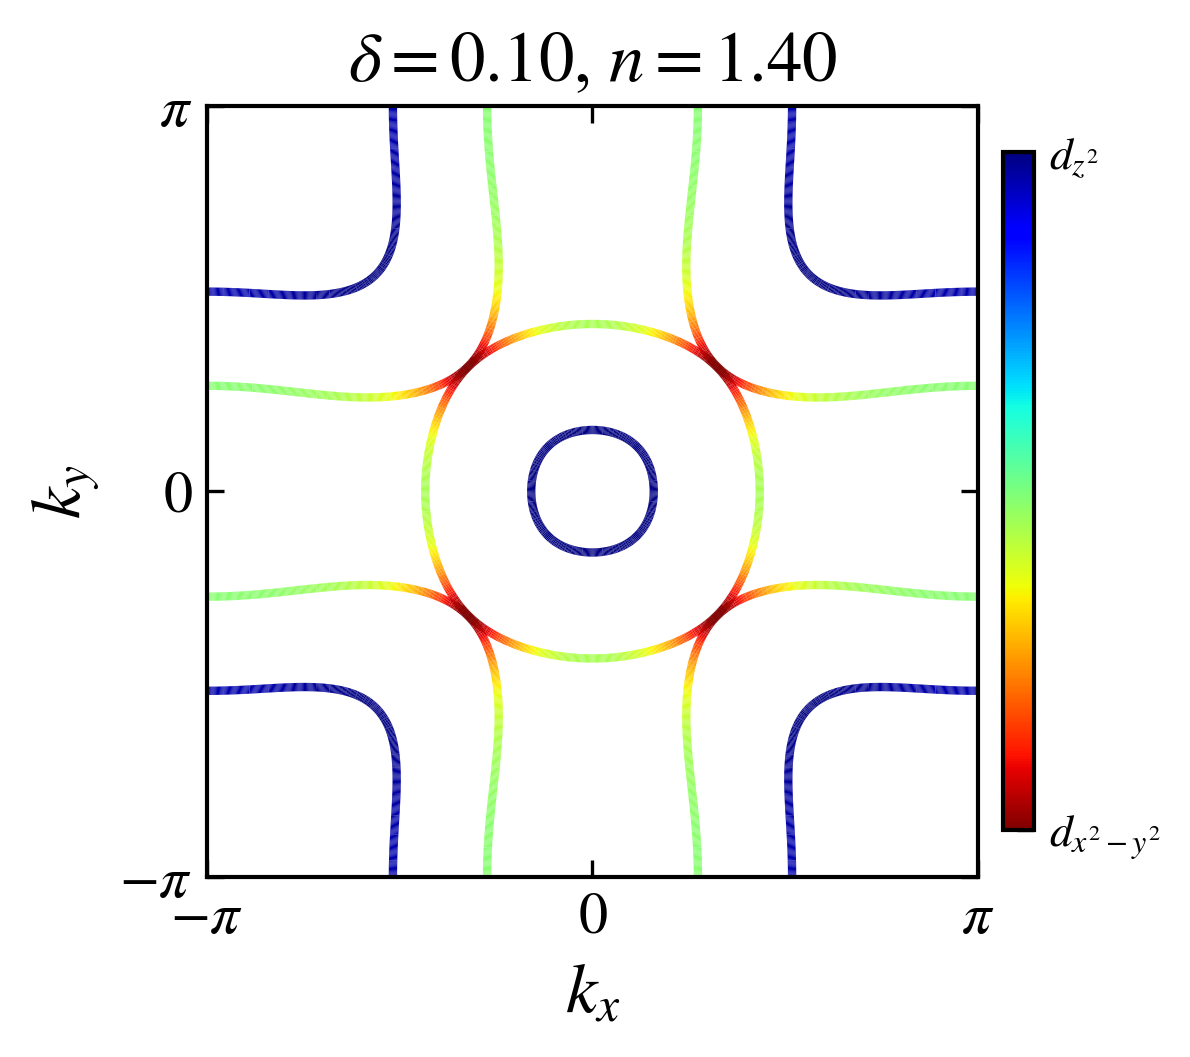

Saved figure: La3Ni2O7_film_Fig3_TB/figures/fig3_FS_delta_0p23.png


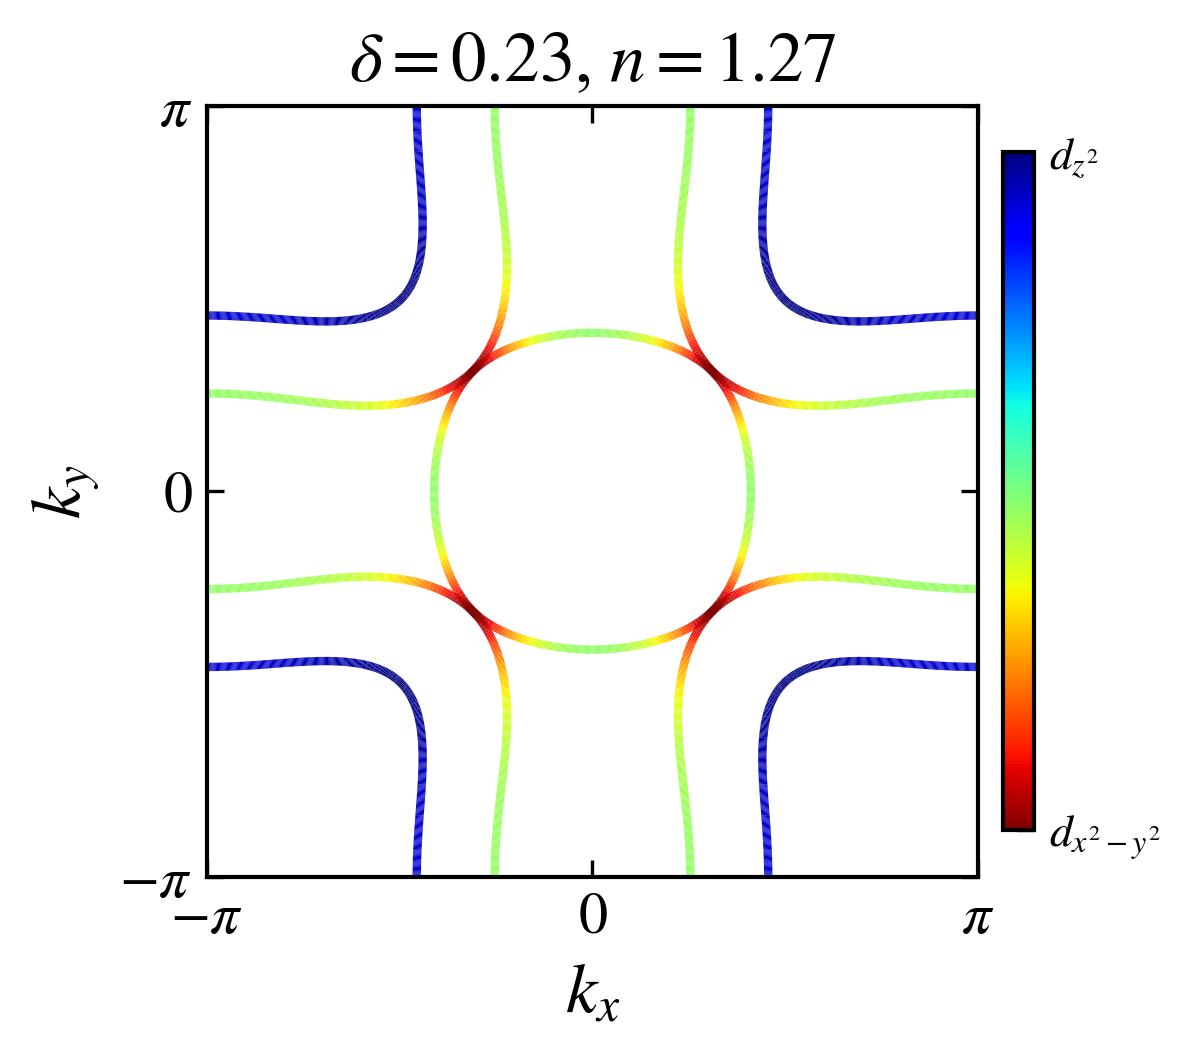

In [ ]:
import os
import json
import time
from dataclasses import dataclass, field, asdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.interpolate import RegularGridInterpolator


# =========================================================
# Parameters of the four-band TB model
# Basis: (tz, tx, bz, bx)
#
# z = d_{z^2}
# x = d_{x^2-y^2}
# t/b = top/bottom layer
# =========================================================
@dataclass
class TBParams:
    # Table I, units: eV
    t1x: float = -0.4501
    t2x: float = 0.0615
    t3x: float = -0.0651
    tperp_x: float = 0.0027
    tperp1_x: float = 0.0

    t1z: float = -0.1248
    t2z: float = -0.0205
    t3z: float = -0.0110
    tperp_z: float = -0.4060
    tperp1_z: float = 0.0360

    t3xz: float = 0.2217
    t4xz: float = -0.0289

    eps_x: float = 0.8898
    eps_z: float = 0.4218


@dataclass
class CalcParams:
    n_path: int = 301
    n_fs: int = 701

    # Fig. 3 uses delta = 0.10 and 0.23
    delta_values: tuple = (0.10, 0.23)

    # Small temperature only for smooth chemical-potential search
    mu_temperature: float = 1.0e-4

    output_dir: str = "La3Ni2O7_film_Fig3_TB"
    band_data_filename: str = "fig3_band_data_TB.npz"
    fs_data_filename: str = "fig3_fs_data_TB.npz"


@dataclass
class PlotParams:
    dpi: int = 300

    figsize_band: tuple = (4.8, 4.0)
    figsize_fs: tuple = (4.2, 4.0)

    font_size: float = 15
    label_size: float = 17
    tick_size: float = 14
    legend_size: float = 10

    # Band plot
    band_lw: float = 2.0

    # Energy window for band plot
    emin: float = -1.3
    emax: float = 2.6

    # Fermi surface plot
    fs_lw: float = 2.0

    # weight_z = 0 -> blue = d_{x^2-y^2}
    # weight_z = 1 -> red  = d_{z^2}
    cmap: str = "coolwarm"

    # colorbar
    cbar_fraction: float = 0.055
    cbar_pad: float = 0.030
    cbar_shrink: float = 0.78
    cbar_aspect: float = 22
    cbar_tick_size: float = 11

    show_figures: bool = True

    fig_dirname: str = "figures"


@dataclass
class Config:
    tb: TBParams = field(default_factory=TBParams)
    calc: CalcParams = field(default_factory=CalcParams)
    plot: PlotParams = field(default_factory=PlotParams)


# =========================================================
# Plot style
# =========================================================
def set_style(cfg):
    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams["mathtext.fontset"] = "stix"

    plt.rcParams["font.size"] = cfg.plot.font_size
    plt.rcParams["axes.linewidth"] = 1.0

    plt.rcParams["xtick.direction"] = "in"
    plt.rcParams["ytick.direction"] = "in"
    plt.rcParams["xtick.top"] = True
    plt.rcParams["ytick.right"] = True

    plt.rcParams["xtick.major.size"] = 4
    plt.rcParams["ytick.major.size"] = 4


# =========================================================
# Four-band Hamiltonian
# =========================================================
def h1_alpha(kx, ky, t1, t2, t3, eps):
    """
    h_1^alpha =
      2 t1 (cos kx + cos ky)
    + 2 t3 [cos(2kx) + cos(2ky)]
    + 2 t2 [cos(kx+ky) + cos(kx-ky)]
    + eps
    """
    return (
        2.0 * t1 * (np.cos(kx) + np.cos(ky))
        + 2.0 * t3 * (np.cos(2.0 * kx) + np.cos(2.0 * ky))
        + 2.0 * t2 * (np.cos(kx + ky) + np.cos(kx - ky))
        + eps
    )


def h1_z(kx, ky, p):
    return h1_alpha(kx, ky, p.t1z, p.t2z, p.t3z, p.eps_z)


def h1_x(kx, ky, p):
    return h1_alpha(kx, ky, p.t1x, p.t2x, p.t3x, p.eps_x)


def h2_xz(kx, ky, p):
    return 2.0 * p.t3xz * (np.cos(kx) - np.cos(ky))


def h3_alpha(kx, ky, tperp, tperp1):
    """
    h_3^alpha = t_perp^alpha + 2 t_perp1^alpha (cos kx + cos ky)
    """
    return tperp + 2.0 * tperp1 * (np.cos(kx) + np.cos(ky))


def h3_z(kx, ky, p):
    return h3_alpha(kx, ky, p.tperp_z, p.tperp1_z)


def h3_x(kx, ky, p):
    return h3_alpha(kx, ky, p.tperp_x, p.tperp1_x)


def h4_xz(kx, ky, p):
    return 2.0 * p.t4xz * (np.cos(kx) - np.cos(ky))


def hamiltonian_4band_grid(KX, KY, p):
    """
    Vectorized Hamiltonian on a k-grid.

    Basis:
        0: tz
        1: tx
        2: bz
        3: bx

    H_k = [[H1, H2],
           [H2, H1]]

    H1 = [[h1z, h2 ],
          [h2,  h1x]]

    H2 = [[h3z, h4 ],
          [h4,  h3x]]
    """
    h1z = h1_z(KX, KY, p)
    h1x = h1_x(KX, KY, p)
    h2 = h2_xz(KX, KY, p)

    h3z = h3_z(KX, KY, p)
    h3x = h3_x(KX, KY, p)
    h4 = h4_xz(KX, KY, p)

    shape = KX.shape
    H = np.zeros(shape + (4, 4), dtype=float)

    # top-layer block
    H[..., 0, 0] = h1z
    H[..., 1, 1] = h1x
    H[..., 0, 1] = h2
    H[..., 1, 0] = h2

    # bottom-layer block
    H[..., 2, 2] = h1z
    H[..., 3, 3] = h1x
    H[..., 2, 3] = h2
    H[..., 3, 2] = h2

    # interlayer block
    H[..., 0, 2] = h3z
    H[..., 2, 0] = h3z

    H[..., 1, 3] = h3x
    H[..., 3, 1] = h3x

    H[..., 0, 3] = h4
    H[..., 3, 0] = h4

    H[..., 1, 2] = h4
    H[..., 2, 1] = h4

    return H


def diagonalize_grid(KX, KY, p):
    """
    Return eigenvalues/eigenvectors on a grid.

    evals shape:
        (..., 4)

    evecs shape:
        (..., 4, 4), last axis is band index.
    """
    H = hamiltonian_4band_grid(KX, KY, p)
    evals, evecs = np.linalg.eigh(H)
    return evals, evecs


def orbital_weights_from_evecs(evecs):
    """
    Basis: (tz, tx, bz, bx)

    dz2 weight:
        |tz|^2 + |bz|^2

    dx2-y2 weight:
        |tx|^2 + |bx|^2
    """
    wz = np.abs(evecs[..., 0, :]) ** 2 + np.abs(evecs[..., 2, :]) ** 2
    wx = np.abs(evecs[..., 1, :]) ** 2 + np.abs(evecs[..., 3, :]) ** 2
    return wx, wz


# =========================================================
# Chemical potential from hole doping
# =========================================================
def fermi_function(E_minus_mu, T):
    if T <= 0:
        return (E_minus_mu < 0.0).astype(float)

    x = np.clip(E_minus_mu / T, -700.0, 700.0)
    return 1.0 / (np.exp(x) + 1.0)


def spinless_filling_at_mu(energies, mu, T):
    """
    energies shape: (Nk, Nk, 4)

    Article uses:
        n = 1.5 - delta.

    With spin degeneracy, the total electron number per unit cell is 2n.
    Therefore the spinless filling of the four-band model is n.
    """
    occ = fermi_function(energies - mu, T)
    return np.mean(np.sum(occ, axis=-1))


def find_mu_for_delta(energies, delta, cfg):
    """
    Solve spinless filling:
        n = 1.5 - delta.
    """
    target_n = 1.5 - delta
    T = cfg.calc.mu_temperature

    emin = np.min(energies) - 2.0
    emax = np.max(energies) + 2.0

    lo = emin
    hi = emax

    for _ in range(200):
        mid = 0.5 * (lo + hi)
        n_mid = spinless_filling_at_mu(energies, mid, T)

        if n_mid < target_n:
            lo = mid
        else:
            hi = mid

        if abs(hi - lo) < 1e-12:
            break

    mu = 0.5 * (lo + hi)
    n_check = spinless_filling_at_mu(energies, mu, T)

    return mu, target_n, n_check


# =========================================================
# High-symmetry path: Gamma-X-M-Gamma
# =========================================================
def make_high_symmetry_path(n_per_segment):
    Gamma = np.array([0.0, 0.0])
    X = np.array([np.pi, 0.0])
    M = np.array([np.pi, np.pi])

    nodes = [Gamma, X, M, Gamma]
    labels = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]

    k_points = []
    k_dist = []
    k_node = [0.0]

    for iseg in range(len(nodes) - 1):
        start = nodes[iseg]
        end = nodes[iseg + 1]

        for j in range(n_per_segment):
            t = j / float(n_per_segment)
            k = start + t * (end - start)

            if len(k_points) == 0:
                dist = 0.0
            else:
                dist = k_dist[-1] + np.linalg.norm(k - k_points[-1])

            k_points.append(k)
            k_dist.append(dist)

        segment_len = np.linalg.norm(end - start)
        k_node.append(k_dist[-1] + segment_len / float(n_per_segment))

    k_points.append(nodes[-1])
    k_dist.append(k_node[-1])

    return np.array(k_points), np.array(k_dist), np.array(k_node), labels


# =========================================================
# Data calculation
# =========================================================
def compute_band_data(cfg):
    os.makedirs(cfg.calc.output_dir, exist_ok=True)

    k_points, k_dist, k_node, labels = make_high_symmetry_path(
        cfg.calc.n_path
    )

    KX = k_points[:, 0]
    KY = k_points[:, 1]

    evals, evecs = diagonalize_grid(KX, KY, cfg.tb)
    wx, wz = orbital_weights_from_evecs(evecs)

    out_file = os.path.join(cfg.calc.output_dir, cfg.calc.band_data_filename)

    np.savez_compressed(
        out_file,
        k_points=k_points,
        k_dist=k_dist,
        k_node=k_node,
        labels=np.array(labels),
        energies=evals,
        weight_x=wx,
        weight_z=wz,
        cfg_json=json.dumps(asdict(cfg), indent=2),
    )

    print(f"Saved band data: {out_file}")
    return out_file


def compute_fs_data(cfg):
    os.makedirs(cfg.calc.output_dir, exist_ok=True)

    kx_values = np.linspace(-np.pi, np.pi, cfg.calc.n_fs, endpoint=True)
    ky_values = np.linspace(-np.pi, np.pi, cfg.calc.n_fs, endpoint=True)

    KX, KY = np.meshgrid(kx_values, ky_values, indexing="xy")

    evals, evecs = diagonalize_grid(KX, KY, cfg.tb)
    wx, wz = orbital_weights_from_evecs(evecs)

    mu_dict = {}

    for delta in cfg.calc.delta_values:
        mu, target_n, n_check = find_mu_for_delta(evals, delta, cfg)
        key = f"delta_{delta:.3f}"

        mu_dict[key] = {
            "delta": float(delta),
            "target_n": float(target_n),
            "mu": float(mu),
            "n_check": float(n_check),
        }

        print(
            f"delta = {delta:.3f}, "
            f"target n = {target_n:.6f}, "
            f"mu = {mu:.10f} eV, "
            f"n_check = {n_check:.8f}"
        )

    out_file = os.path.join(cfg.calc.output_dir, cfg.calc.fs_data_filename)

    np.savez_compressed(
        out_file,
        kx_values=kx_values,
        ky_values=ky_values,
        energies=evals,
        weight_x=wx,
        weight_z=wz,
        mu_json=json.dumps(mu_dict, indent=2),
        cfg_json=json.dumps(asdict(cfg), indent=2),
    )

    print(f"Saved FS data: {out_file}")
    return out_file


def run_calculation(cfg):
    t0 = time.perf_counter()

    print("=" * 72)
    print("Calculating Fig. 3 TB data for La3Ni2O7 film")
    print("=" * 72)
    print("basis          = (tz, tx, bz, bx)")
    print(f"n_path         = {cfg.calc.n_path}")
    print(f"n_fs           = {cfg.calc.n_fs}")
    print(f"delta_values   = {cfg.calc.delta_values}")
    print("=" * 72)

    band_file = compute_band_data(cfg)
    fs_file = compute_fs_data(cfg)

    elapsed = time.perf_counter() - t0

    print("=" * 72)
    print(f"Finished. Elapsed time: {elapsed:.3f} s")
    print("=" * 72)

    return band_file, fs_file


# =========================================================
# Data loading
# =========================================================
def load_band_data(cfg):
    data_file = os.path.join(cfg.calc.output_dir, cfg.calc.band_data_filename)

    if not os.path.exists(data_file):
        raise FileNotFoundError(
            f"Cannot find band data:\n{data_file}\n"
            "Please run compute_band_data(cfg) first."
        )

    data = np.load(data_file, allow_pickle=True)

    return {
        "k_points": data["k_points"],
        "k_dist": data["k_dist"],
        "k_node": data["k_node"],
        "labels": list(data["labels"]),
        "energies": data["energies"],
        "weight_x": data["weight_x"],
        "weight_z": data["weight_z"],
        "data_file": data_file,
    }


def load_fs_data(cfg):
    data_file = os.path.join(cfg.calc.output_dir, cfg.calc.fs_data_filename)

    if not os.path.exists(data_file):
        raise FileNotFoundError(
            f"Cannot find FS data:\n{data_file}\n"
            "Please run compute_fs_data(cfg) first."
        )

    data = np.load(data_file, allow_pickle=True)
    mu_dict = json.loads(str(data["mu_json"]))

    return {
        "kx_values": data["kx_values"],
        "ky_values": data["ky_values"],
        "energies": data["energies"],
        "weight_x": data["weight_x"],
        "weight_z": data["weight_z"],
        "mu_dict": mu_dict,
        "data_file": data_file,
    }


# =========================================================
# Figure utilities
# =========================================================
def make_figure_dir(cfg):
    fig_dir = os.path.join(cfg.calc.output_dir, cfg.plot.fig_dirname)
    os.makedirs(fig_dir, exist_ok=True)
    return fig_dir


def colored_line(ax, x, y, c, cmap, norm, lw):
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    c_mid = 0.5 * (c[:-1] + c[1:])

    lc = LineCollection(
        segments,
        cmap=cmap,
        norm=norm,
        linewidth=lw,
    )
    lc.set_array(c_mid)
    ax.add_collection(lc)

    return lc


def setup_orbital_colorbar(fig, ax, cfg, sm):
    """
    Color convention:
        0 -> d_{x^2-y^2}
        1 -> d_{z^2}
    """
    cbar = fig.colorbar(
        sm,
        ax=ax,
        pad=cfg.plot.cbar_pad,
        fraction=cfg.plot.cbar_fraction,
        shrink=cfg.plot.cbar_shrink,
        aspect=cfg.plot.cbar_aspect,
    )

    cbar.set_ticks([0.0, 1.0])
    cbar.set_ticklabels(
        [
            r"$d_{x^2-y^2}$",
            r"$d_{z^2}$",
        ]
    )
    cbar.ax.tick_params(labelsize=cfg.plot.cbar_tick_size)

    return cbar


# =========================================================
# Band plot with orbital weight
# =========================================================
def plot_band_structure(cfg):
    set_style(cfg)

    band_data = load_band_data(cfg)
    fs_data = load_fs_data(cfg)

    k_dist = band_data["k_dist"]
    k_node = band_data["k_node"]
    labels = band_data["labels"]
    energies = band_data["energies"]
    weight_z = band_data["weight_z"]

    fig, ax = plt.subplots(
        figsize=cfg.plot.figsize_band,
        dpi=cfg.plot.dpi,
    )

    cmap = plt.get_cmap(cfg.plot.cmap)
    norm = Normalize(vmin=0.0, vmax=1.0)

    n_band = energies.shape[1]

    for ib in range(n_band):
        colored_line(
            ax=ax,
            x=k_dist,
            y=energies[:, ib],
            c=weight_z[:, ib],
            cmap=cmap,
            norm=norm,
            lw=cfg.plot.band_lw,
        )

    # Fermi levels for two dopings
    colors_mu = {
        "delta_0.100": "gray",
        "delta_0.230": "purple",
    }

    for key, entry in fs_data["mu_dict"].items():
        delta = entry["delta"]
        mu = entry["mu"]

        color = colors_mu.get(key, "gray")
        ax.axhline(
            mu,
            color=color,
            ls="--",
            lw=1.0,
            alpha=0.95,
            label=rf"$\delta={delta:.2f}$",
        )

    for xnode in k_node:
        ax.axvline(
            xnode,
            color="black",
            lw=0.8,
            alpha=0.45,
        )

    ax.set_xlim(k_dist[0], k_dist[-1])
    ax.set_ylim(cfg.plot.emin, cfg.plot.emax)

    ax.set_xticks(k_node)
    ax.set_xticklabels(labels)

    ax.set_yticks([cfg.plot.emin, 0.0, cfg.plot.emax])
    ax.set_ylabel(r"$E$ (eV)", fontsize=cfg.plot.label_size)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=cfg.plot.tick_size,
    )

    ax.legend(
        frameon=False,
        fontsize=cfg.plot.legend_size,
        loc="lower right",
    )

    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    setup_orbital_colorbar(fig, ax, cfg, sm)

    fig.tight_layout()

    fig_dir = make_figure_dir(cfg)
    out_png = os.path.join(fig_dir, "fig3a_TB_band_structure_orbital_weight.png")

    fig.savefig(out_png, bbox_inches="tight")
    print(f"Saved figure: {out_png}")

    if cfg.plot.show_figures:
        plt.show()

    plt.close(fig)

    return out_png


# =========================================================
# Fermi surface contour
# =========================================================
def get_contour_segments(x_values, y_values, Z, level=0.0):
    fig_tmp, ax_tmp = plt.subplots()

    CS = ax_tmp.contour(
        x_values,
        y_values,
        Z,
        levels=[level],
    )

    segments = CS.allsegs[0]
    plt.close(fig_tmp)

    clean_segments = [seg for seg in segments if seg.shape[0] >= 2]
    return clean_segments


def add_colored_fs_contours(
    ax,
    kx_values,
    ky_values,
    E_band_minus_mu,
    W_band,
    cmap,
    norm,
    lw,
):
    segments = get_contour_segments(
        kx_values,
        ky_values,
        E_band_minus_mu,
        level=0.0,
    )

    if len(segments) == 0:
        return []

    interp = RegularGridInterpolator(
        (ky_values, kx_values),
        W_band,
        method="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    collections = []

    for seg in segments:
        # seg[:, 0] = kx, seg[:, 1] = ky
        pts_interp = np.column_stack([seg[:, 1], seg[:, 0]])
        w = interp(pts_interp)

        valid = np.isfinite(w)

        if np.sum(valid) < 2:
            continue

        seg = seg[valid]
        w = w[valid]

        points = seg.reshape(-1, 1, 2)
        sub_segments = np.concatenate([points[:-1], points[1:]], axis=1)
        w_mid = 0.5 * (w[:-1] + w[1:])

        lc = LineCollection(
            sub_segments,
            cmap=cmap,
            norm=norm,
            linewidth=lw,
        )
        lc.set_array(w_mid)

        ax.add_collection(lc)
        collections.append(lc)

    return collections


def plot_fermi_surface_for_delta(cfg, delta):
    set_style(cfg)

    data = load_fs_data(cfg)

    kx_values = data["kx_values"]
    ky_values = data["ky_values"]
    energies = data["energies"]
    weight_z = data["weight_z"]

    key = f"delta_{delta:.3f}"

    if key not in data["mu_dict"]:
        raise ValueError(f"delta={delta} not found in saved mu_dict.")

    mu = data["mu_dict"][key]["mu"]
    n_target = data["mu_dict"][key]["target_n"]

    fig, ax = plt.subplots(
        figsize=cfg.plot.figsize_fs,
        dpi=cfg.plot.dpi,
    )

    cmap = plt.get_cmap(cfg.plot.cmap)
    norm = Normalize(vmin=0.0, vmax=1.0)

    n_band = energies.shape[2]

    for ib in range(n_band):
        add_colored_fs_contours(
            ax=ax,
            kx_values=kx_values,
            ky_values=ky_values,
            E_band_minus_mu=energies[:, :, ib] - mu,
            W_band=weight_z[:, :, ib],
            cmap=cmap,
            norm=norm,
            lw=cfg.plot.fs_lw,
        )

    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(-np.pi, np.pi)
    ax.set_aspect("equal")

    ax.set_xticks([-np.pi, 0.0, np.pi])
    ax.set_yticks([-np.pi, 0.0, np.pi])

    ax.set_xticklabels([r"$-\pi$", r"$0$", r"$\pi$"])
    ax.set_yticklabels([r"$-\pi$", r"$0$", r"$\pi$"])

    ax.set_xlabel(r"$k_x$", fontsize=cfg.plot.label_size)
    ax.set_ylabel(r"$k_y$", fontsize=cfg.plot.label_size)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=cfg.plot.tick_size,
    )

    ax.set_title(
        rf"$\delta={delta:.2f}$, $n={n_target:.2f}$",
        fontsize=cfg.plot.label_size,
    )

    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    setup_orbital_colorbar(fig, ax, cfg, sm)

    fig.tight_layout()

    fig_dir = make_figure_dir(cfg)

    delta_str = f"{delta:.2f}".replace(".", "p")
    out_png = os.path.join(
        fig_dir,
        f"fig3_FS_delta_{delta_str}.png",
    )

    fig.savefig(out_png, bbox_inches="tight")
    print(f"Saved figure: {out_png}")

    if cfg.plot.show_figures:
        plt.show()

    plt.close(fig)

    return out_png


def run_plotting(cfg):
    print("=" * 72)
    print("Plotting Fig. 3 TB results from saved data")
    print("=" * 72)

    band_fig = plot_band_structure(cfg)

    fs_figs = []
    for delta in cfg.calc.delta_values:
        fs_figs.append(plot_fermi_surface_for_delta(cfg, delta))

    return band_fig, fs_figs


# =========================================================
# Build config
# =========================================================
def build_config():
    cfg = Config()

    # =====================================================
    # Calculation
    # =====================================================
    cfg.calc.n_path = 301
    cfg.calc.n_fs = 701

    cfg.calc.delta_values = (0.10, 0.23)
    cfg.calc.mu_temperature = 1.0e-4

    cfg.calc.output_dir = "La3Ni2O7_film_Fig3_TB"
    cfg.calc.band_data_filename = "fig3_band_data_TB.npz"
    cfg.calc.fs_data_filename = "fig3_fs_data_TB.npz"

    # =====================================================
    # Plot
    # =====================================================
    cfg.plot.dpi = 300

    cfg.plot.figsize_band = (4.8, 4.0)
    cfg.plot.figsize_fs = (4.2, 4.0)

    cfg.plot.emin = -1.3
    cfg.plot.emax = 2.6

    cfg.plot.band_lw = 2.0
    cfg.plot.fs_lw = 2.0

    # weight_z = 0 -> blue = d_{x^2-y^2}
    # weight_z = 1 -> red  = d_{z^2}
    cfg.plot.cmap = "jet_r"

    cfg.plot.cbar_fraction = 0.055
    cfg.plot.cbar_pad = 0.030
    cfg.plot.cbar_shrink = 0.78
    cfg.plot.cbar_aspect = 22

    cfg.plot.show_figures = True

    return cfg


# =========================================================
# Main switch for ipynb
# =========================================================
cfg = build_config()

# First run:
#   RUN_CALC = True
#   RUN_PLOT = True
#
# Later, only adjust plotting:
#   RUN_CALC = False
#   RUN_PLOT = True

RUN_CALC = False
RUN_PLOT = True

if RUN_CALC:
    run_calculation(cfg)

if RUN_PLOT:
    run_plotting(cfg)

## 自旋磁化率

Fig. 4(b,e): RPA spin susceptibility for La3Ni2O7 film
basis              = (tz, tx, bz, bx)
Nk                 = 81 x 81
q_stride           = 2
parallel_backend   = thread
n_workers          = 4
delta_values       = (0.1, 0.23)
U_mode             = fixed
eta                = 0.01
delta = 0.100
target n = 1.40000000, mu = 0.1202882784 eV, n_check = 1.40000000
Computing chi0 for 1681 q points
  chi0 progress: 168/1681
  chi0 progress: 336/1681
  chi0 progress: 504/1681
  chi0 progress: 672/1681
  chi0 progress: 840/1681
  chi0 progress: 1008/1681
  chi0 progress: 1176/1681
  chi0 progress: 1344/1681
  chi0 progress: 1512/1681
  chi0 progress: 1680/1681
  chi0 progress: 1681/1681
chi0 calculation finished in 81.772 s
max eig[chi0 Us(U=1)] = 1.23602768, Uc = 0.80904337 eV, U used = 0.60000000 eV
chi_s map min/max = -3.88578059e-16, 6.62253763e+00
delta = 0.230
target n = 1.27000000, mu = 0.0568384980 eV, n_check = 1.27000000
Computing chi0 for 1681 q points
  chi0 progress: 168/1681
  chi

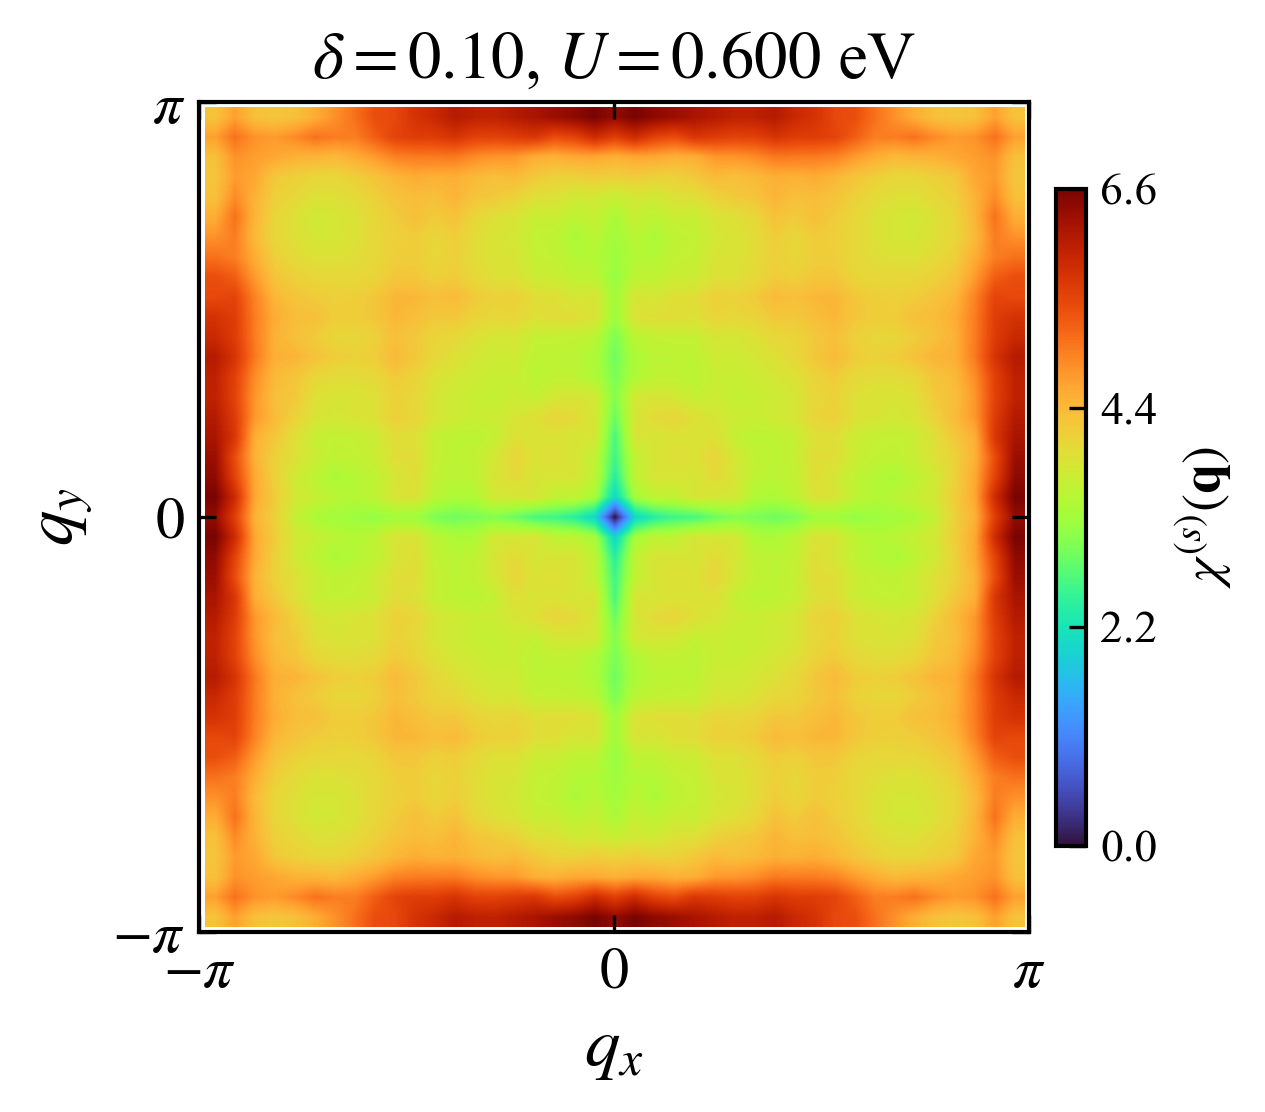

Saved figure: La3Ni2O7_film_Fig4_RPA_chi/figures/fig4_RPA_spin_chi_delta_0p23.png


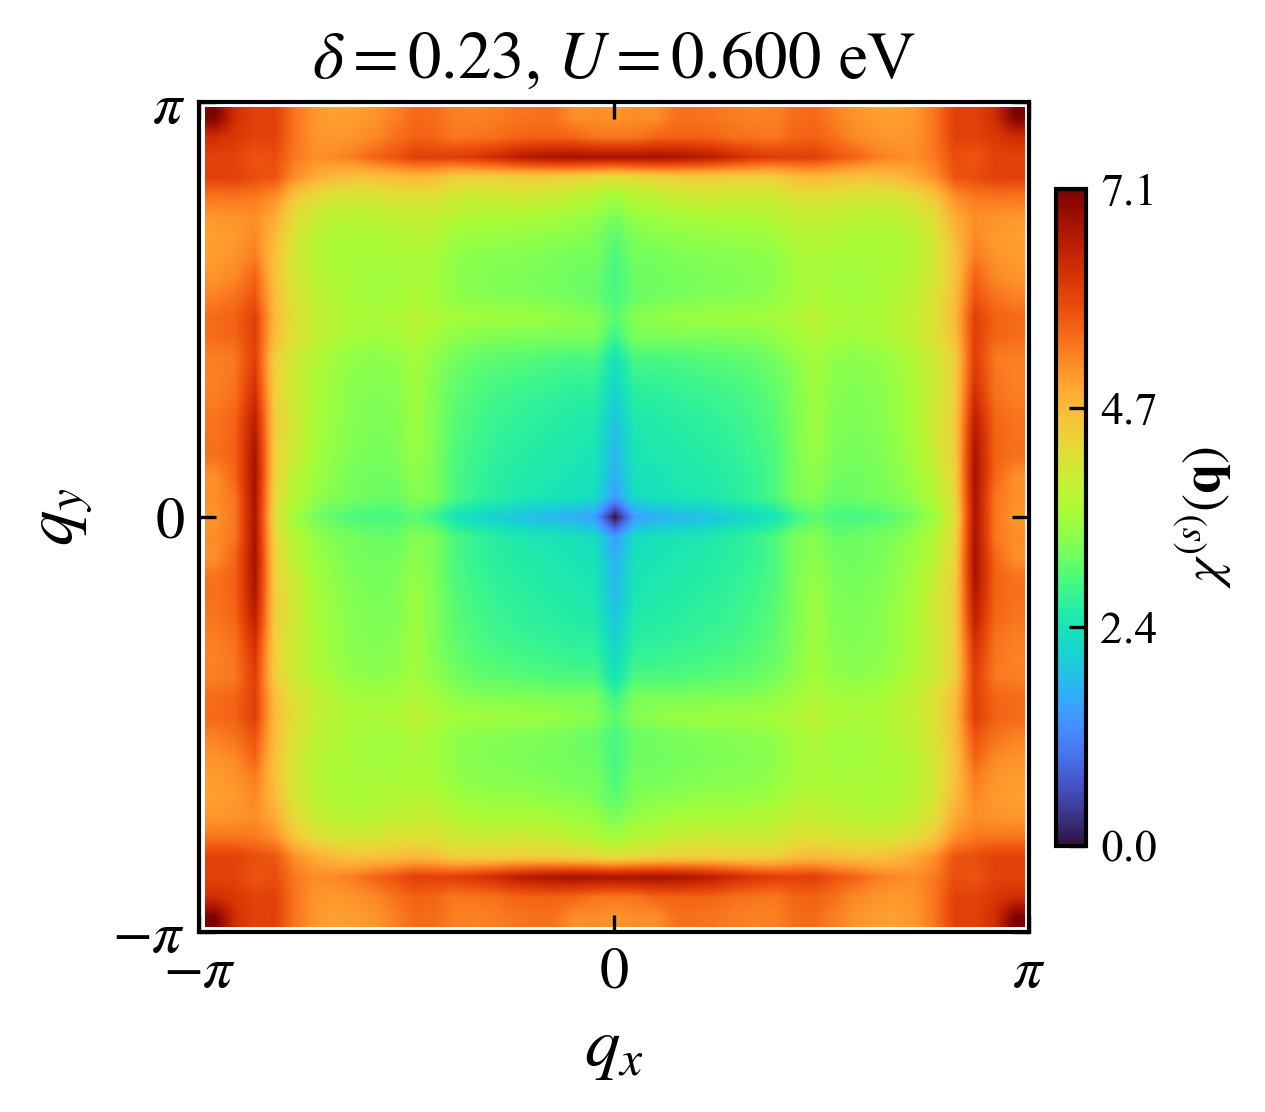

In [ ]:
import os
import json
import time
from dataclasses import dataclass, field, asdict
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# =========================================================
# Four-band TB parameters
# Basis: (tz, tx, bz, bx)
# z = d_{z^2}
# x = d_{x^2-y^2}
# t/b = top/bottom layer
# =========================================================
@dataclass
class TBParams:
    # Table I, units: eV
    t1x: float = -0.4501
    t2x: float = 0.0615
    t3x: float = -0.0651
    tperp_x: float = 0.0027
    tperp1_x: float = 0.0

    t1z: float = -0.1248
    t2z: float = -0.0205
    t3z: float = -0.0110
    tperp_z: float = -0.4060
    tperp1_z: float = 0.0360

    t3xz: float = 0.2217
    t4xz: float = -0.0289

    eps_x: float = 0.8898
    eps_z: float = 0.4218


@dataclass
class RPAParams:
    # U mode:
    #   "fixed": use U_fixed
    #   "fraction_of_Uc": estimate Uc from max eig[chi0 Us(U=1)] and use U_fraction * Uc
    U_mode: str = "fraction_of_Uc"

    U_fixed: float = 0.60
    U_fraction_of_Uc: float = 0.95

    # JH = U / 6, V = U - 2 JH = 2U/3
    JH_ratio: float = 1.0 / 6.0

    # Static susceptibility
    omega: float = 0.0

    # Broadening in eV
    eta: float = 0.01

    # Temperature in eV. Use 0 for step-function occupation.
    temperature: float = 0.0

    # Physical spin susceptibility aggregation:
    #   "diagdiag": sum_{p,s} chi^{pp}_{ss}
    #   "all":      sum over full 16x16 matrix
    aggregate_mode: str = "diagdiag"


@dataclass
class CalcParams:
    # k mesh. Start from 81 in ipynb; increase to 101/121 for cleaner figures.
    Nk: int = 81

    # q grid from integer shifts of k mesh.
    # q_stride=2 is much faster; q_stride=1 is finer.
    q_stride: int = 2

    # If None: use full shifts [-Nk//2, Nk//2].
    # Otherwise restrict to [-q_max_shift, q_max_shift].
    q_max_shift: object = None

    delta_values: tuple = (0.10, 0.23)

    # Small temperature only for smooth chemical-potential search
    mu_temperature: float = 1.0e-4

    # Parallel settings for mac + ipynb:
    #   "thread" is safe.
    #   "serial" is useful for debugging.
    parallel_backend: str = "thread"
    n_workers: int = 4

    # Save chi0 matrices. Usually False because it increases file size.
    save_chi0: bool = False

    output_dir: str = "La3Ni2O7_film_Fig4_RPA_chi"
    data_filename: str = "fig4_RPA_spin_chi_data.npz"


@dataclass
class PlotParams:
    dpi: int = 300

    figsize_single: tuple = (4.4, 4.0)
    figsize_combined: tuple = (8.4, 3.8)

    font_size: float = 15
    label_size: float = 17
    tick_size: float = 14
    title_size: float = 16

    cmap: str = "turbo"
    interpolation: str = "bilinear"

    # If True, both delta=0.10 and 0.23 use the same color scale.
    use_common_color_scale: bool = False

    # If None, determined automatically.
    vmin: float = 0.0
    vmax: object = None

    # Colorbar
    n_cbar_ticks: int = 4
    cbar_decimal: int = 1
    cbar_fraction: float = 0.050
    cbar_pad: float = 0.030
    cbar_shrink: float = 0.78
    cbar_aspect: float = 22
    cbar_label_size: float = 13
    cbar_tick_size: float = 11

    show_figures: bool = True

    make_separate_figures: bool = True
    make_combined_figure: bool = True

    fig_dirname: str = "figures"


@dataclass
class Config:
    tb: TBParams = field(default_factory=TBParams)
    rpa: RPAParams = field(default_factory=RPAParams)
    calc: CalcParams = field(default_factory=CalcParams)
    plot: PlotParams = field(default_factory=PlotParams)


# =========================================================
# Plot style
# =========================================================
def set_style(cfg):
    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams["mathtext.fontset"] = "stix"

    plt.rcParams["font.size"] = cfg.plot.font_size
    plt.rcParams["axes.linewidth"] = 1.0

    plt.rcParams["xtick.direction"] = "in"
    plt.rcParams["ytick.direction"] = "in"
    plt.rcParams["xtick.top"] = True
    plt.rcParams["ytick.right"] = True

    plt.rcParams["xtick.major.size"] = 4
    plt.rcParams["ytick.major.size"] = 4


# =========================================================
# Four-band Hamiltonian
# =========================================================
def h1_alpha(kx, ky, t1, t2, t3, eps):
    return (
        2.0 * t1 * (np.cos(kx) + np.cos(ky))
        + 2.0 * t3 * (np.cos(2.0 * kx) + np.cos(2.0 * ky))
        + 2.0 * t2 * (np.cos(kx + ky) + np.cos(kx - ky))
        + eps
    )


def h1_z(kx, ky, p):
    return h1_alpha(kx, ky, p.t1z, p.t2z, p.t3z, p.eps_z)


def h1_x(kx, ky, p):
    return h1_alpha(kx, ky, p.t1x, p.t2x, p.t3x, p.eps_x)


def h2_xz(kx, ky, p):
    return 2.0 * p.t3xz * (np.cos(kx) - np.cos(ky))


def h3_alpha(kx, ky, tperp, tperp1):
    return tperp + 2.0 * tperp1 * (np.cos(kx) + np.cos(ky))


def h3_z(kx, ky, p):
    return h3_alpha(kx, ky, p.tperp_z, p.tperp1_z)


def h3_x(kx, ky, p):
    return h3_alpha(kx, ky, p.tperp_x, p.tperp1_x)


def h4_xz(kx, ky, p):
    return 2.0 * p.t4xz * (np.cos(kx) - np.cos(ky))


def hamiltonian_4band_grid(KX, KY, p):
    """
    Basis:
        0: tz
        1: tx
        2: bz
        3: bx
    """
    h1z = h1_z(KX, KY, p)
    h1x = h1_x(KX, KY, p)
    h2 = h2_xz(KX, KY, p)

    h3z = h3_z(KX, KY, p)
    h3x = h3_x(KX, KY, p)
    h4 = h4_xz(KX, KY, p)

    shape = KX.shape
    H = np.zeros(shape + (4, 4), dtype=float)

    H[..., 0, 0] = h1z
    H[..., 1, 1] = h1x
    H[..., 0, 1] = h2
    H[..., 1, 0] = h2

    H[..., 2, 2] = h1z
    H[..., 3, 3] = h1x
    H[..., 2, 3] = h2
    H[..., 3, 2] = h2

    H[..., 0, 2] = h3z
    H[..., 2, 0] = h3z

    H[..., 1, 3] = h3x
    H[..., 3, 1] = h3x

    H[..., 0, 3] = h4
    H[..., 3, 0] = h4

    H[..., 1, 2] = h4
    H[..., 2, 1] = h4

    return H


def diagonalize_grid(KX, KY, p):
    H = hamiltonian_4band_grid(KX, KY, p)
    evals, evecs = np.linalg.eigh(H)
    return evals, evecs


# =========================================================
# k mesh, q mesh, filling
# =========================================================
def make_kmesh(cfg):
    Nk = cfg.calc.Nk
    k_values = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
    KX, KY = np.meshgrid(k_values, k_values, indexing="xy")
    return k_values, k_values, KX, KY


def make_q_shifts(cfg):
    Nk = cfg.calc.Nk

    if cfg.calc.q_max_shift is None:
        max_shift = Nk // 2
    else:
        max_shift = int(cfg.calc.q_max_shift)

    stride = int(cfg.calc.q_stride)

    shifts = np.arange(
        -max_shift,
        max_shift + 1,
        stride,
        dtype=int,
    )

    dk = 2.0 * np.pi / Nk
    q_values = shifts * dk

    return shifts, q_values


def fermi_function(E_minus_mu, T):
    if T <= 0:
        return (E_minus_mu < 0.0).astype(float)

    x = np.clip(E_minus_mu / T, -700.0, 700.0)
    return 1.0 / (np.exp(x) + 1.0)


def spinless_filling_at_mu(energies, mu, T):
    occ = fermi_function(energies - mu, T)
    return np.mean(np.sum(occ, axis=-1))


def find_mu_for_delta(energies, delta, cfg):
    target_n = 1.5 - delta
    T = cfg.calc.mu_temperature

    lo = np.min(energies) - 2.0
    hi = np.max(energies) + 2.0

    for _ in range(220):
        mid = 0.5 * (lo + hi)
        n_mid = spinless_filling_at_mu(energies, mid, T)

        if n_mid < target_n:
            lo = mid
        else:
            hi = mid

        if abs(hi - lo) < 1e-12:
            break

    mu = 0.5 * (lo + hi)
    n_check = spinless_filling_at_mu(energies, mu, T)

    return mu, target_n, n_check


# =========================================================
# Interaction vertex U^(s)
# =========================================================
def orbital_layer(orb):
    """
    Basis: (tz, tx, bz, bx)
    top layer: 0,1
    bottom layer: 2,3
    """
    if orb in (0, 1):
        return 0
    return 1


def same_layer_four(p, q, s, t):
    lp = orbital_layer(p)
    return (
        orbital_layer(q) == lp
        and orbital_layer(s) == lp
        and orbital_layer(t) == lp
    )


def build_Us_matrix(U, cfg):
    """
    Build spin-channel interaction matrix U^(s).

    Matrix indices:
        row = (p, q)
        col = (s, t)

    0-based orbitals:
        0: tz
        1: tx
        2: bz
        3: bx
    """
    JH = cfg.rpa.JH_ratio * U
    V = U - 2.0 * JH

    norb = 4
    Us = np.zeros((norb * norb, norb * norb), dtype=complex)

    for p in range(norb):
        for q in range(norb):
            row = p * norb + q

            for s in range(norb):
                for t in range(norb):
                    col = s * norb + t

                    value = 0.0

                    if p == q == s == t:
                        value = U

                    elif same_layer_four(p, q, s, t):
                        # (p=q) != (s=t)
                        if (p == q) and (s == t) and (p != s):
                            value = JH

                        # (p=s) != (q=t)
                        elif (p == s) and (q == t) and (p != q):
                            value = JH

                        # (p=t) != (q=s)
                        elif (p == t) and (q == s) and (p != q):
                            value = V

                    Us[row, col] = value

    return Us


# =========================================================
# Bare susceptibility chi0
# =========================================================
def roll_kplusq(array, shift_x, shift_y):
    """
    array axis:
        0: ky
        1: kx

    k + q corresponds to ix -> ix + shift_x, iy -> iy + shift_y.
    """
    out = np.roll(array, shift=-shift_y, axis=0)
    out = np.roll(out, shift=-shift_x, axis=1)
    return out


def compute_chi0_for_shift(evals_mu, evecs, focc, shift_x, shift_y, cfg):
    r"""
    Compute chi0^{pq}_{st}(q, omega=0).

    Implemented formula:

        chi0^{pq}_{st}(q) =
        1/N sum_{k,m,n}
        xi_p^{n*}(k)
        xi_q^{m}(k+q)
        xi_s^{m*}(k+q)
        xi_t^{n}(k)
        *
        [f(e_m(k+q)) - f(e_n(k))]
        /
        [e_n(k) - e_m(k+q) + i eta]
    """
    eta = cfg.rpa.eta
    omega = cfg.rpa.omega

    Nk = cfg.calc.Nk
    norb = 4
    nband = 4

    evals_q = roll_kplusq(evals_mu, shift_x, shift_y)
    evecs_q = roll_kplusq(evecs, shift_x, shift_y)
    focc_q = roll_kplusq(focc, shift_x, shift_y)

    chi0_tensor = np.zeros((norb, norb, norb, norb), dtype=complex)

    for n in range(nband):
        eps_n = evals_mu[:, :, n]
        f_n = focc[:, :, n]
        u_n = evecs[:, :, :, n]

        for m in range(nband):
            eps_m_q = evals_q[:, :, m]
            f_m_q = focc_q[:, :, m]
            u_m_q = evecs_q[:, :, :, m]

            numerator = f_m_q - f_n
            denominator = omega + eps_n - eps_m_q + 1j * eta

            kernel = numerator / denominator

            # p q s t tensor
            # conj(u_n[p]) * u_m_q[q] * conj(u_m_q[s]) * u_n[t]
            chi0_tensor += np.einsum(
                "ij,ijp,ijq,ijs,ijt->pqst",
                kernel,
                np.conj(u_n),
                u_m_q,
                np.conj(u_m_q),
                u_n,
                optimize=True,
            )

    chi0_tensor /= float(Nk * Nk)

    chi0_matrix = chi0_tensor.reshape(norb * norb, norb * norb)

    return chi0_matrix


# =========================================================
# RPA and physical spin susceptibility
# =========================================================
def compute_spin_chi_rpa(chi0, Us):
    I = np.eye(chi0.shape[0], dtype=complex)
    A = I - chi0 @ Us

    try:
        chi_s = np.linalg.solve(A, chi0)
    except np.linalg.LinAlgError:
        chi_s = np.linalg.pinv(A) @ chi0

    return chi_s


def aggregate_spin_susceptibility(chi_s, cfg):
    norb = 4

    if cfg.rpa.aggregate_mode == "diagdiag":
        val = 0.0 + 0.0j
        for p in range(norb):
            row = p * norb + p
            for s in range(norb):
                col = s * norb + s
                val += chi_s[row, col]
        return float(np.real(val))

    if cfg.rpa.aggregate_mode == "all":
        return float(np.real(np.sum(chi_s)))

    raise ValueError("aggregate_mode must be 'diagdiag' or 'all'.")


def estimate_Uc_from_chi0(chi0_all, cfg):
    """
    Since JH and V are proportional to U, U^(s) scales linearly with U.
    Estimate Uc from max eigenvalue of chi0 * Us(U=1).
    """
    Us_unit = build_Us_matrix(1.0, cfg)

    max_lam = -np.inf

    nq_y, nq_x = chi0_all.shape[:2]

    for iy in range(nq_y):
        for ix in range(nq_x):
            M = chi0_all[iy, ix] @ Us_unit
            eigvals = np.linalg.eigvals(M)
            lam = np.max(np.real(eigvals))
            if lam > max_lam:
                max_lam = lam

    if max_lam <= 0:
        return np.inf, max_lam

    Uc = 1.0 / max_lam

    return Uc, max_lam


# =========================================================
# Parallel chi0 calculation
# =========================================================
def compute_chi0_all_q(evals_mu, evecs, focc, shifts, cfg):
    n_q = len(shifts)
    chi0_all = np.zeros((n_q, n_q, 16, 16), dtype=complex)

    jobs = []
    for iqy, sy in enumerate(shifts):
        for iqx, sx in enumerate(shifts):
            jobs.append((iqy, iqx, int(sx), int(sy)))

    total_jobs = len(jobs)

    print(f"Computing chi0 for {total_jobs} q points")

    t0 = time.perf_counter()

    if cfg.calc.parallel_backend == "serial":
        done = 0

        for iqy, iqx, sx, sy in jobs:
            chi0_all[iqy, iqx] = compute_chi0_for_shift(
                evals_mu,
                evecs,
                focc,
                sx,
                sy,
                cfg,
            )

            done += 1
            if done % max(1, total_jobs // 10) == 0 or done == total_jobs:
                print(f"  chi0 progress: {done}/{total_jobs}")

    elif cfg.calc.parallel_backend == "thread":
        done = 0

        def worker(job):
            iqy, iqx, sx, sy = job
            chi0 = compute_chi0_for_shift(
                evals_mu,
                evecs,
                focc,
                sx,
                sy,
                cfg,
            )
            return iqy, iqx, chi0

        with ThreadPoolExecutor(max_workers=cfg.calc.n_workers) as executor:
            futures = [executor.submit(worker, job) for job in jobs]

            for fut in as_completed(futures):
                iqy, iqx, chi0 = fut.result()
                chi0_all[iqy, iqx] = chi0

                done += 1
                if done % max(1, total_jobs // 10) == 0 or done == total_jobs:
                    print(f"  chi0 progress: {done}/{total_jobs}")

    else:
        raise ValueError("parallel_backend must be 'serial' or 'thread'.")

    elapsed = time.perf_counter() - t0
    print(f"chi0 calculation finished in {elapsed:.3f} s")

    return chi0_all


# =========================================================
# Main calculation
# =========================================================
def run_calculation(cfg):
    os.makedirs(cfg.calc.output_dir, exist_ok=True)

    t0 = time.perf_counter()

    print("=" * 72)
    print("Fig. 4(b,e): RPA spin susceptibility for La3Ni2O7 film")
    print("=" * 72)
    print("basis              = (tz, tx, bz, bx)")
    print(f"Nk                 = {cfg.calc.Nk} x {cfg.calc.Nk}")
    print(f"q_stride           = {cfg.calc.q_stride}")
    print(f"parallel_backend   = {cfg.calc.parallel_backend}")
    print(f"n_workers          = {cfg.calc.n_workers}")
    print(f"delta_values       = {cfg.calc.delta_values}")
    print(f"U_mode             = {cfg.rpa.U_mode}")
    print(f"eta                = {cfg.rpa.eta}")
    print("=" * 72)

    kx_values, ky_values, KX, KY = make_kmesh(cfg)
    evals_raw, evecs = diagonalize_grid(KX, KY, cfg.tb)

    shifts, q_values = make_q_shifts(cfg)
    n_q = len(shifts)

    chi_maps = np.zeros((len(cfg.calc.delta_values), n_q, n_q), dtype=float)
    mu_values = np.zeros(len(cfg.calc.delta_values), dtype=float)
    n_targets = np.zeros(len(cfg.calc.delta_values), dtype=float)
    n_checks = np.zeros(len(cfg.calc.delta_values), dtype=float)
    Uc_values = np.zeros(len(cfg.calc.delta_values), dtype=float)
    U_used_values = np.zeros(len(cfg.calc.delta_values), dtype=float)
    max_lambda_values = np.zeros(len(cfg.calc.delta_values), dtype=float)

    chi0_save_dict = {}

    for idelta, delta in enumerate(cfg.calc.delta_values):
        print("=" * 72)
        print(f"delta = {delta:.3f}")
        print("=" * 72)

        mu, n_target, n_check = find_mu_for_delta(evals_raw, delta, cfg)

        mu_values[idelta] = mu
        n_targets[idelta] = n_target
        n_checks[idelta] = n_check

        print(
            f"target n = {n_target:.8f}, "
            f"mu = {mu:.10f} eV, "
            f"n_check = {n_check:.8f}"
        )

        evals_mu = evals_raw - mu
        focc = fermi_function(evals_mu, cfg.rpa.temperature)

        chi0_all = compute_chi0_all_q(
            evals_mu=evals_mu,
            evecs=evecs,
            focc=focc,
            shifts=shifts,
            cfg=cfg,
        )

        Uc, max_lam = estimate_Uc_from_chi0(chi0_all, cfg)

        Uc_values[idelta] = Uc
        max_lambda_values[idelta] = max_lam

        if cfg.rpa.U_mode == "fixed":
            U_used = cfg.rpa.U_fixed
        elif cfg.rpa.U_mode == "fraction_of_Uc":
            U_used = cfg.rpa.U_fraction_of_Uc * Uc
        else:
            raise ValueError("U_mode must be 'fixed' or 'fraction_of_Uc'.")

        U_used_values[idelta] = U_used

        print(
            f"max eig[chi0 Us(U=1)] = {max_lam:.8f}, "
            f"Uc = {Uc:.8f} eV, "
            f"U used = {U_used:.8f} eV"
        )

        Us = build_Us_matrix(U_used, cfg)

        chi_map = np.zeros((n_q, n_q), dtype=float)

        for iqy in range(n_q):
            for iqx in range(n_q):
                chi_s = compute_spin_chi_rpa(
                    chi0=chi0_all[iqy, iqx],
                    Us=Us,
                )

                chi_map[iqy, iqx] = aggregate_spin_susceptibility(
                    chi_s,
                    cfg,
                )

        chi_maps[idelta] = chi_map

        print(
            f"chi_s map min/max = "
            f"{np.nanmin(chi_map):.8e}, {np.nanmax(chi_map):.8e}"
        )

        if cfg.calc.save_chi0:
            chi0_save_dict[f"chi0_delta_{delta:.3f}"] = chi0_all

    out_file = os.path.join(
        cfg.calc.output_dir,
        cfg.calc.data_filename,
    )

    save_dict = {
        "delta_values": np.array(cfg.calc.delta_values, dtype=float),
        "kx_values": kx_values,
        "ky_values": ky_values,
        "q_values": q_values,
        "q_shifts": shifts,
        "mu_values": mu_values,
        "n_targets": n_targets,
        "n_checks": n_checks,
        "Uc_values": Uc_values,
        "U_used_values": U_used_values,
        "max_lambda_values": max_lambda_values,
        "chi_maps": chi_maps,
        "cfg_json": json.dumps(asdict(cfg), indent=2),
    }

    save_dict.update(chi0_save_dict)

    np.savez_compressed(out_file, **save_dict)

    elapsed = time.perf_counter() - t0

    print("=" * 72)
    print(f"Saved data: {out_file}")
    print(f"Total elapsed: {elapsed:.3f} s")
    print("=" * 72)

    return out_file


# =========================================================
# Load data
# =========================================================
def load_chi_data(cfg):
    data_file = os.path.join(
        cfg.calc.output_dir,
        cfg.calc.data_filename,
    )

    if not os.path.exists(data_file):
        raise FileNotFoundError(
            f"Cannot find data file:\n{data_file}\n"
            "Please run run_calculation(cfg) first."
        )

    data = np.load(data_file, allow_pickle=True)

    return {
        "delta_values": data["delta_values"],
        "q_values": data["q_values"],
        "q_shifts": data["q_shifts"],
        "mu_values": data["mu_values"],
        "n_targets": data["n_targets"],
        "n_checks": data["n_checks"],
        "Uc_values": data["Uc_values"],
        "U_used_values": data["U_used_values"],
        "max_lambda_values": data["max_lambda_values"],
        "chi_maps": data["chi_maps"],
        "data_file": data_file,
    }


# =========================================================
# Plotting
# =========================================================
def make_figure_dir(cfg):
    fig_dir = os.path.join(cfg.calc.output_dir, cfg.plot.fig_dirname)
    os.makedirs(fig_dir, exist_ok=True)
    return fig_dir


def format_tick(x, pos, decimal=1):
    threshold = 0.5 * 10 ** (-decimal)
    if abs(x) < threshold:
        x = 0.0
    return f"{x:.{decimal}f}"


def add_colorbar(fig, ax, im, cfg):
    cbar = fig.colorbar(
        im,
        ax=ax,
        pad=cfg.plot.cbar_pad,
        fraction=cfg.plot.cbar_fraction,
        shrink=cfg.plot.cbar_shrink,
        aspect=cfg.plot.cbar_aspect,
    )

    cbar.set_label(
        r"$\chi^{(s)}(\mathbf{q})$",
        fontsize=cfg.plot.cbar_label_size,
    )

    ticks = np.linspace(im.norm.vmin, im.norm.vmax, cfg.plot.n_cbar_ticks)
    cbar.set_ticks(ticks)

    cbar.ax.yaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: format_tick(
                x,
                pos,
                decimal=cfg.plot.cbar_decimal,
            )
        )
    )

    cbar.ax.tick_params(labelsize=cfg.plot.cbar_tick_size)

    return cbar


def setup_q_axis(ax, cfg):
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)

    ax.set_xticks([-1.0, 0.0, 1.0])
    ax.set_yticks([-1.0, 0.0, 1.0])

    ax.set_xticklabels([r"$-\pi$", r"$0$", r"$\pi$"])
    ax.set_yticklabels([r"$-\pi$", r"$0$", r"$\pi$"])

    ax.set_xlabel(r"$q_x$", fontsize=cfg.plot.label_size)
    ax.set_ylabel(r"$q_y$", fontsize=cfg.plot.label_size)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=cfg.plot.tick_size,
    )

    ax.set_aspect("equal")


def get_color_limits(chi_maps, cfg):
    if cfg.plot.vmax is not None:
        vmax = cfg.plot.vmax
    else:
        vmax = np.nanmax(chi_maps)

    vmin = cfg.plot.vmin

    return vmin, vmax


def plot_single_delta_map(cfg, data, idelta, vmin=None, vmax=None):
    set_style(cfg)

    delta = float(data["delta_values"][idelta])
    chi_map = data["chi_maps"][idelta]
    q_values = data["q_values"]
    Uc = data["Uc_values"][idelta]
    U_used = data["U_used_values"][idelta]
    mu = data["mu_values"][idelta]

    q_plot = q_values / np.pi

    if vmin is None:
        vmin = cfg.plot.vmin

    if vmax is None:
        vmax = np.nanmax(chi_map)

    fig, ax = plt.subplots(
        figsize=cfg.plot.figsize_single,
        dpi=cfg.plot.dpi,
    )

    im = ax.imshow(
        chi_map,
        origin="lower",
        extent=[
            q_plot[0],
            q_plot[-1],
            q_plot[0],
            q_plot[-1],
        ],
        cmap=cfg.plot.cmap,
        interpolation=cfg.plot.interpolation,
        aspect="equal",
        vmin=vmin,
        vmax=vmax,
    )

    setup_q_axis(ax, cfg)

    ax.set_title(
        rf"$\delta={delta:.2f}$, $U={U_used:.3f}$ eV",
        fontsize=cfg.plot.title_size,
    )

    add_colorbar(fig, ax, im, cfg)

    fig.tight_layout()

    fig_dir = make_figure_dir(cfg)
    delta_str = f"{delta:.2f}".replace(".", "p")

    out_png = os.path.join(
        fig_dir,
        f"fig4_RPA_spin_chi_delta_{delta_str}.png",
    )

    fig.savefig(out_png, bbox_inches="tight")
    print(f"Saved figure: {out_png}")

    if cfg.plot.show_figures:
        plt.show()

    plt.close(fig)

    return out_png



def run_plotting(cfg):
    data = load_chi_data(cfg)

    print("=" * 72)
    print("Plotting Fig. 4(b,e) RPA spin susceptibility")
    print("=" * 72)
    print(f"Loaded: {data['data_file']}")

    for i, delta in enumerate(data["delta_values"]):
        print(
            f"delta={delta:.3f}, "
            f"mu={data['mu_values'][i]:.8f}, "
            f"Uc={data['Uc_values'][i]:.8f}, "
            f"U_used={data['U_used_values'][i]:.8f}"
        )

    print("=" * 72)

    if cfg.plot.use_common_color_scale:
        vmin, vmax = get_color_limits(data["chi_maps"], cfg)
    else:
        vmin, vmax = None, None

    if cfg.plot.make_separate_figures:
        for idelta in range(len(data["delta_values"])):
            plot_single_delta_map(
                cfg=cfg,
                data=data,
                idelta=idelta,
                vmin=vmin,
                vmax=vmax,
            )


# =========================================================
# Build config
# =========================================================
def build_config():
    cfg = Config()

    # =====================================================
    # Calculation
    # =====================================================
    # Start from 81 for mac + ipynb.
    # Increase to 101 or 121 for better figures.
    cfg.calc.Nk = 81

    # q_stride=2 is faster.
    # q_stride=1 is finer but much slower.
    cfg.calc.q_stride = 2
    cfg.calc.q_max_shift = None

    cfg.calc.delta_values = (0.10, 0.23)
    cfg.calc.mu_temperature = 1.0e-4

    # For mac + ipynb, thread is safer than process.
    cfg.calc.parallel_backend = "thread"
    cfg.calc.n_workers = 4

    cfg.calc.save_chi0 = False

    cfg.calc.output_dir = "La3Ni2O7_film_Fig4_RPA_chi"

    # =====================================================
    # RPA settings
    # =====================================================
    # Recommended first: fraction_of_Uc. This gives clear RPA enhancement
    # without manually knowing Uc.
    cfg.rpa.U_mode = "fixed"   # fraction_of_Uc, fixed
    cfg.rpa.U_fraction_of_Uc = 0.95

    # Used only if U_mode = "fixed"
    cfg.rpa.U_fixed = 0.60

    # JH=U/6, V=2U/3
    cfg.rpa.JH_ratio = 1.0 / 6.0

    cfg.rpa.eta = 0.01
    cfg.rpa.temperature = 0.0
    cfg.rpa.omega = 0.0

    cfg.rpa.aggregate_mode = "diagdiag"

    cfg.calc.data_filename = (
        f"fig4_RPA_chi_"
        f"Nk{cfg.calc.Nk}_"
        f"qstride{cfg.calc.q_stride}_"
        f"eta{cfg.rpa.eta}_"
        f"{cfg.rpa.U_mode}.npz"
    )

    # =====================================================
    # Plot
    # =====================================================
    cfg.plot.dpi = 300

    cfg.plot.figsize_single = (4.4, 4.0)
    cfg.plot.figsize_combined = (8.4, 3.8)

    cfg.plot.cmap = "turbo"
    cfg.plot.interpolation = "bilinear"

    # If True, two panels share one color scale.
    # For comparison with the paper, False often shows each peak more clearly.
    cfg.plot.use_common_color_scale = False

    cfg.plot.vmin = 0.0
    cfg.plot.vmax = None

    cfg.plot.n_cbar_ticks = 4
    cfg.plot.cbar_decimal = 1

    cfg.plot.make_separate_figures = True
    cfg.plot.make_combined_figure = True

    cfg.plot.show_figures = True

    return cfg


# =========================================================
# Main switch for ipynb
# =========================================================
cfg = build_config()

# First run:
#   RUN_CALC = True
#   RUN_PLOT = True
#
# Later, only adjust plotting:
#   RUN_CALC = False
#   RUN_PLOT = True

RUN_CALC = True
RUN_PLOT = True

if RUN_CALC:
    run_calculation(cfg)

if RUN_PLOT:
    run_plotting(cfg)

### Julia并行计算

In [ ]:
# ============================================================
# main.jl
#
# RPA spin susceptibility for La3Ni2O7 thin-film four-band model
# Basis: (tz, tx, bz, bx)
#
# Output:
#   qx  qy  chis
#
# Run:
#   mpiexec -n 8 julia main.jl
#   or
#   srun -n 128 julia main.jl
# ============================================================

using MPI
using LinearAlgebra
using Printf
using Dates

# ============================================================
# MPI initialization
# ============================================================
MPI.Init()

const COMM = MPI.COMM_WORLD
const RANK = MPI.Comm_rank(COMM)
const NRANKS = MPI.Comm_size(COMM)


# ============================================================
# Parameter containers
# ============================================================

Base.@kwdef struct TBParams
    # Table I, units eV
    t1x::Float64 = -0.4501
    t2x::Float64 =  0.0615
    t3x::Float64 = -0.0651
    tperp_x::Float64 = 0.0027
    tperp1_x::Float64 = 0.0

    t1z::Float64 = -0.1248
    t2z::Float64 = -0.0205
    t3z::Float64 = -0.0110
    tperp_z::Float64 = -0.4060
    tperp1_z::Float64 = 0.0360

    t3xz::Float64 = 0.2217
    t4xz::Float64 = -0.0289

    eps_x::Float64 = 0.8898
    eps_z::Float64 = 0.4218
end


Base.@kwdef struct Config
    # k/q mesh
    Nk::Int = 128
    q_stride::Int = 1
    q_max_shift::Union{Nothing, Int} = nothing

    # dopings
    delta_list::Vector{Float64} = [0.10, 0.23]

    # chemical-potential search
    mu_temperature::Float64 = 1.0e-4

    # RPA interaction
    # "fixed" or "fraction_of_Uc"
    U_mode::String = "fraction_of_Uc"
    U_fixed::Float64 = 0.60
    U_fraction_of_Uc::Float64 = 0.95

    # JH = JH_ratio * U, V = U - 2JH
    JH_ratio::Float64 = 1.0 / 6.0

    # static susceptibility
    omega::Float64 = 0.0
    eta::Float64 = 0.01
    temperature::Float64 = 0.0

    # output scalar definition
    # "diagdiag": sum_{p,s} chi^{pp}_{ss}
    # "all":      sum over all 16 x 16 matrix elements
    aggregate_mode::String = "diagdiag"

    # BLAS threads per MPI rank
    blas_threads::Int = 1

    # output
    output_dir::String = "La3Ni2O7_film_Fig4_RPA_chi_julia"
    save_q_in_pi_units::Bool = true
end


# ============================================================
# Utility printing
# ============================================================

function root_println(args...)
    if RANK == 0
        println(args...)
        flush(stdout)
    end
end

function root_printf(fmt::AbstractString, args...)
    if RANK == 0
        print(Printf.format(Printf.Format(fmt), args...))
        flush(stdout)
    end
end


# ============================================================
# TB model
# Basis:
#   1: tz
#   2: tx
#   3: bz
#   4: bx
# ============================================================

@inline function h1_alpha(kx, ky, t1, t2, t3, eps)
    return (
        2.0 * t1 * (cos(kx) + cos(ky)) +
        2.0 * t3 * (cos(2.0 * kx) + cos(2.0 * ky)) +
        2.0 * t2 * (cos(kx + ky) + cos(kx - ky)) +
        eps
    )
end

@inline h1_z(kx, ky, p::TBParams) = h1_alpha(kx, ky, p.t1z, p.t2z, p.t3z, p.eps_z)
@inline h1_x(kx, ky, p::TBParams) = h1_alpha(kx, ky, p.t1x, p.t2x, p.t3x, p.eps_x)

@inline h2_xz(kx, ky, p::TBParams) = 2.0 * p.t3xz * (cos(kx) - cos(ky))

@inline function h3_alpha(kx, ky, tperp, tperp1)
    return tperp + 2.0 * tperp1 * (cos(kx) + cos(ky))
end

@inline h3_z(kx, ky, p::TBParams) = h3_alpha(kx, ky, p.tperp_z, p.tperp1_z)
@inline h3_x(kx, ky, p::TBParams) = h3_alpha(kx, ky, p.tperp_x, p.tperp1_x)

@inline h4_xz(kx, ky, p::TBParams) = 2.0 * p.t4xz * (cos(kx) - cos(ky))


function hamiltonian_4band!(H::Matrix{Float64}, kx::Float64, ky::Float64, p::TBParams)
    h1z = h1_z(kx, ky, p)
    h1x = h1_x(kx, ky, p)
    h2  = h2_xz(kx, ky, p)

    h3z = h3_z(kx, ky, p)
    h3x = h3_x(kx, ky, p)
    h4  = h4_xz(kx, ky, p)

    fill!(H, 0.0)

    # Top layer
    H[1, 1] = h1z
    H[2, 2] = h1x
    H[1, 2] = h2
    H[2, 1] = h2

    # Bottom layer
    H[3, 3] = h1z
    H[4, 4] = h1x
    H[3, 4] = h2
    H[4, 3] = h2

    # Interlayer
    H[1, 3] = h3z
    H[3, 1] = h3z

    H[2, 4] = h3x
    H[4, 2] = h3x

    H[1, 4] = h4
    H[4, 1] = h4

    H[2, 3] = h4
    H[3, 2] = h4

    return nothing
end


# ============================================================
# Mesh and eigensystem
# ============================================================

function make_k_values(Nk::Int)
    return collect(range(-pi, stop=pi, length=Nk + 1))[1:Nk]
end


function compute_eigensystem(Nk::Int, p::TBParams)
    kvals = make_k_values(Nk)

    evals = Array{Float64}(undef, Nk, Nk, 4)
    evecs = Array{ComplexF64}(undef, Nk, Nk, 4, 4)

    H = zeros(Float64, 4, 4)

    for iy in 1:Nk
        ky = kvals[iy]

        for ix in 1:Nk
            kx = kvals[ix]

            hamiltonian_4band!(H, kx, ky, p)
            F = eigen(Symmetric(H))

            for n in 1:4
                evals[iy, ix, n] = F.values[n]

                for a in 1:4
                    evecs[iy, ix, a, n] = ComplexF64(F.vectors[a, n])
                end
            end
        end
    end

    return kvals, evals, evecs
end


# ============================================================
# Filling and chemical potential
# ============================================================

@inline function fermi_scalar(x::Float64, T::Float64)
    if T <= 0.0
        return x < 0.0 ? 1.0 : 0.0
    end

    y = clamp(x / T, -700.0, 700.0)
    return 1.0 / (exp(y) + 1.0)
end


function spinless_filling(evals::Array{Float64,3}, mu::Float64, T::Float64)
    Nk = size(evals, 1)
    occ_sum = 0.0

    @inbounds for iy in 1:Nk, ix in 1:Nk, n in 1:4
        occ_sum += fermi_scalar(evals[iy, ix, n] - mu, T)
    end

    return occ_sum / (Nk * Nk)
end


function find_mu_for_delta(evals::Array{Float64,3}, delta::Float64, cfg::Config)
    target_n = 1.5 - delta

    lo = minimum(evals) - 2.0
    hi = maximum(evals) + 2.0

    for _ in 1:220
        mid = 0.5 * (lo + hi)
        n_mid = spinless_filling(evals, mid, cfg.mu_temperature)

        if n_mid < target_n
            lo = mid
        else
            hi = mid
        end

        if abs(hi - lo) < 1.0e-12
            break
        end
    end

    mu = 0.5 * (lo + hi)
    n_check = spinless_filling(evals, mu, cfg.mu_temperature)

    return mu, target_n, n_check
end


function occupations_shifted(evals::Array{Float64,3}, mu::Float64, cfg::Config)
    Nk = size(evals, 1)

    evals_mu = Array{Float64}(undef, Nk, Nk, 4)
    focc = Array{Float64}(undef, Nk, Nk, 4)

    @inbounds for iy in 1:Nk, ix in 1:Nk, n in 1:4
        emu = evals[iy, ix, n] - mu
        evals_mu[iy, ix, n] = emu
        focc[iy, ix, n] = fermi_scalar(emu, cfg.temperature)
    end

    return evals_mu, focc
end


# ============================================================
# q-grid
# ============================================================

function make_q_shifts(cfg::Config)
    max_shift = cfg.q_max_shift === nothing ? div(cfg.Nk, 2) : Int(cfg.q_max_shift)
    shifts = collect(-max_shift:cfg.q_stride:max_shift)
    dk = 2.0 * pi / cfg.Nk
    qvals = shifts .* dk

    return shifts, qvals
end


@inline function wrap_index(i::Int, shift::Int, Nk::Int)
    return mod(i - 1 + shift, Nk) + 1
end


# ============================================================
# Interaction matrix U^(s)
# Matrix indices:
#   row = (p,q)
#   col = (s,t)
# idx(p,q) = (p-1)*4 + q
# ============================================================

@inline function idx2(a::Int, b::Int)
    return (a - 1) * 4 + b
end


@inline function orbital_layer(orb::Int)
    # 1:tz, 2:tx top
    # 3:bz, 4:bx bottom
    return orb <= 2 ? 1 : 2
end


@inline function same_layer_four(p::Int, q::Int, s::Int, t::Int)
    lp = orbital_layer(p)
    return orbital_layer(q) == lp &&
           orbital_layer(s) == lp &&
           orbital_layer(t) == lp
end


function build_Us_matrix(U::Float64, cfg::Config)
    JH = cfg.JH_ratio * U
    V  = U - 2.0 * JH

    Us = zeros(ComplexF64, 16, 16)

    for p in 1:4, q in 1:4
        row = idx2(p, q)

        for s in 1:4, t in 1:4
            col = idx2(s, t)
            value = 0.0

            if p == q && q == s && s == t
                value = U

            elseif same_layer_four(p, q, s, t)

                # p = q != s = t
                if (p == q) && (s == t) && (p != s)
                    value = JH

                # p = s != q = t
                elseif (p == s) && (q == t) && (p != q)
                    value = JH

                # p = t != q = s
                elseif (p == t) && (q == s) && (p != q)
                    value = V
                end
            end

            Us[row, col] = ComplexF64(value, 0.0)
        end
    end

    return Us
end


# ============================================================
# Bare susceptibility chi0 by outer-product update
# No BLAS.geru! is used here for compatibility.
# ============================================================

@inline function fill_outer_vectors!(
    avec::Vector{ComplexF64},
    bvec::Vector{ComplexF64},
    evecs::Array{ComplexF64,4},
    iy::Int,
    ix::Int,
    jy::Int,
    jx::Int,
    n::Int,
    m::Int,
)
    # row index: (p,q)
    # avec[pq] = conj(u_n[p,k]) * u_m[q,k+q]
    ind = 1

    @inbounds for p in 1:4
        cn_p = conj(evecs[iy, ix, p, n])

        for q in 1:4
            avec[ind] = cn_p * evecs[jy, jx, q, m]
            ind += 1
        end
    end

    # col index: (s,t)
    # bvec[st] = conj(u_m[s,k+q]) * u_n[t,k]
    ind = 1

    @inbounds for s in 1:4
        cm_s = conj(evecs[jy, jx, s, m])

        for t in 1:4
            bvec[ind] = cm_s * evecs[iy, ix, t, n]
            ind += 1
        end
    end

    return nothing
end


@inline function outer_update_16!(
    C::Matrix{ComplexF64},
    alpha::ComplexF64,
    x::Vector{ComplexF64},
    y::Vector{ComplexF64},
)
    # C += alpha * x * transpose(y)
    # This is intentionally written manually because BLAS.geru!
    # may not be available in some Julia builds.
    @inbounds for j in 1:16
        aj = alpha * y[j]

        for i in 1:16
            C[i, j] += x[i] * aj
        end
    end

    return nothing
end


function compute_chi0_shift_outer!(
    chi0::Matrix{ComplexF64},
    evals_mu::Array{Float64,3},
    evecs::Array{ComplexF64,4},
    focc::Array{Float64,3},
    shift_x::Int,
    shift_y::Int,
    cfg::Config,
    avec::Vector{ComplexF64},
    bvec::Vector{ComplexF64},
)
    Nk = size(evals_mu, 1)

    fill!(chi0, 0.0 + 0.0im)

    @inbounds for iy in 1:Nk
        jy = wrap_index(iy, shift_y, Nk)

        for ix in 1:Nk
            jx = wrap_index(ix, shift_x, Nk)

            for n in 1:4
                eps_n = evals_mu[iy, ix, n]
                f_n = focc[iy, ix, n]

                for m in 1:4
                    eps_mq = evals_mu[jy, jx, m]
                    f_mq = focc[jy, jx, m]

                    numerator = f_mq - f_n
                    denominator = ComplexF64(cfg.omega + eps_n - eps_mq, cfg.eta)
                    kernel = numerator / denominator

                    if abs(kernel) < 1.0e-18
                        continue
                    end

                    fill_outer_vectors!(
                        avec,
                        bvec,
                        evecs,
                        iy,
                        ix,
                        jy,
                        jx,
                        n,
                        m,
                    )

                    outer_update_16!(
                        chi0,
                        kernel,
                        avec,
                        bvec,
                    )
                end
            end
        end
    end

    chi0 ./= Float64(Nk * Nk)

    return nothing
end


# ============================================================
# RPA and aggregation
# ============================================================

function compute_chis_scalar(
    chi0::AbstractMatrix{ComplexF64},
    Us::Matrix{ComplexF64},
    cfg::Config,
)
    I16 = Matrix{ComplexF64}(I, 16, 16)
    A = I16 - chi0 * Us

    chi_s = A \ chi0

    if cfg.aggregate_mode == "diagdiag"
        val = 0.0 + 0.0im

        for p in 1:4
            row = idx2(p, p)

            for s in 1:4
                col = idx2(s, s)
                val += chi_s[row, col]
            end
        end

        return real(val)

    elseif cfg.aggregate_mode == "all"
        return real(sum(chi_s))

    else
        error("Unknown aggregate_mode = $(cfg.aggregate_mode)")
    end
end


function estimate_local_max_lambda_from_list(
    chi0_list::Array{ComplexF64,3},
    cfg::Config,
)
    Us_unit = build_Us_matrix(1.0, cfg)

    nlocal = size(chi0_list, 1)
    local_max = -Inf

    for i in 1:nlocal
        chi0 = Matrix(@view chi0_list[i, :, :])
        M = chi0 * Us_unit
        vals = eigvals(M)
        lam = maximum(real(vals))

        if lam > local_max
            local_max = lam
        end
    end

    return local_max
end


# ============================================================
# Job distribution
# ============================================================

function build_q_jobs(shifts)
    jobs = Vector{Tuple{Int,Int,Int,Int}}()

    for (iqy, sy) in enumerate(shifts)
        for (iqx, sx) in enumerate(shifts)
            push!(jobs, (iqy, iqx, sx, sy))
        end
    end

    return jobs
end


function split_jobs_for_rank(jobs)
    local_jobs = Vector{Tuple{Int,Int,Int,Int}}()

    for (ijob, job) in enumerate(jobs)
        if mod(ijob - 1, NRANKS) == RANK
            push!(local_jobs, job)
        end
    end

    return local_jobs
end


# ============================================================
# Local chi0 calculation
# ============================================================

function compute_local_chi0_list(
    evals_mu::Array{Float64,3},
    evecs::Array{ComplexF64,4},
    focc::Array{Float64,3},
    local_jobs,
    cfg::Config,
)
    nlocal = length(local_jobs)

    chi0_list = Array{ComplexF64}(undef, nlocal, 16, 16)

    chi0 = zeros(ComplexF64, 16, 16)
    avec = zeros(ComplexF64, 16)
    bvec = zeros(ComplexF64, 16)

    t0 = time()

    for (iloc, job) in enumerate(local_jobs)
        _, _, sx, sy = job

        compute_chi0_shift_outer!(
            chi0,
            evals_mu,
            evecs,
            focc,
            sx,
            sy,
            cfg,
            avec,
            bvec,
        )

        chi0_list[iloc, :, :] .= chi0

        if RANK == 0 && iloc % max(1, nlocal ÷ 10) == 0
            @printf("rank 0 chi0 local progress: %d/%d\n", iloc, nlocal)
            flush(stdout)
        end
    end

    if RANK == 0
        @printf("rank 0 local chi0 finished in %.3f s\n", time() - t0)
        flush(stdout)
    end

    return chi0_list
end


# ============================================================
# Calculation for one delta
# ============================================================

function calculate_delta!(
    chis_global::Matrix{Float64},
    delta::Float64,
    evals_raw::Array{Float64,3},
    evecs::Array{ComplexF64,4},
    shifts,
    local_jobs,
    cfg::Config,
)
    mu, target_n, n_check = find_mu_for_delta(evals_raw, delta, cfg)

    root_println("="^72)
    root_printf(
        "delta = %.4f, target n = %.8f, mu = %.10f eV, n_check = %.8f\n",
        delta,
        target_n,
        mu,
        n_check,
    )

    evals_mu, focc = occupations_shifted(evals_raw, mu, cfg)

    # Compute local chi0 only once.
    # Then use it both for Uc estimation and RPA chis.
    chi0_list = compute_local_chi0_list(
        evals_mu,
        evecs,
        focc,
        local_jobs,
        cfg,
    )

    # Estimate Uc
    local_max = estimate_local_max_lambda_from_list(chi0_list, cfg)
    global_max = MPI.Allreduce(local_max, MPI.MAX, COMM)

    Uc = global_max > 0.0 ? 1.0 / global_max : Inf

    if cfg.U_mode == "fixed"
        U_used = cfg.U_fixed
    elseif cfg.U_mode == "fraction_of_Uc"
        U_used = cfg.U_fraction_of_Uc * Uc
    else
        error("Unknown U_mode = $(cfg.U_mode)")
    end

    root_printf(
        "max eig[chi0*Us(U=1)] = %.10f, Uc = %.10f eV, U_used = %.10f eV\n",
        global_max,
        Uc,
        U_used,
    )

    Us = build_Us_matrix(U_used, cfg)

    # Compute RPA chi_s(q) from saved local chi0.
    n_q = length(shifts)

    chis_local = zeros(Float64, n_q, n_q)

    for (iloc, job) in enumerate(local_jobs)
        iqy, iqx, _, _ = job
        chi0 = Matrix(@view chi0_list[iloc, :, :])

        chis_local[iqy, iqx] = compute_chis_scalar(chi0, Us, cfg)
    end

    MPI.Allreduce!(chis_local, chis_global, MPI.SUM, COMM)

    root_printf(
        "chis min/max = %.8e, %.8e\n",
        minimum(chis_global),
        maximum(chis_global),
    )

    return mu, target_n, n_check, Uc, U_used, global_max
end


# ============================================================
# Output
# ============================================================

function delta_string(delta::Float64)
    return replace(@sprintf("%.2f", delta), "." => "p")
end


function save_chis_dat(
    filename::String,
    qvals,
    chis::Matrix{Float64},
    delta::Float64,
    mu::Float64,
    target_n::Float64,
    n_check::Float64,
    Uc::Float64,
    U_used::Float64,
    max_lambda::Float64,
    cfg::Config,
)
    open(filename, "w") do io
        println(io, "# RPA spin susceptibility chi^(s)(q)")
        println(io, "# Basis: (tz, tx, bz, bx)")
        println(io, "# Columns: qx qy chis")
        println(io, "# qx,qy units: ", cfg.save_q_in_pi_units ? "pi" : "absolute radians")
        @printf(io, "# delta = %.8f\n", delta)
        @printf(io, "# n_target = %.12f\n", target_n)
        @printf(io, "# n_check = %.12f\n", n_check)
        @printf(io, "# mu = %.12f eV\n", mu)
        @printf(io, "# Uc = %.12f eV\n", Uc)
        @printf(io, "# U_used = %.12f eV\n", U_used)
        @printf(io, "# max_lambda_U1 = %.12f\n", max_lambda)
        @printf(io, "# Nk = %d\n", cfg.Nk)
        @printf(io, "# q_stride = %d\n", cfg.q_stride)
        @printf(io, "# eta = %.12f\n", cfg.eta)
        @printf(io, "# temperature = %.12f\n", cfg.temperature)
        @printf(io, "# U_mode = %s\n", cfg.U_mode)
        @printf(io, "# aggregate_mode = %s\n", cfg.aggregate_mode)
        println(io, "# Generated: ", Dates.now())

        nq = length(qvals)

        for iqy in 1:nq
            for iqx in 1:nq
                qx = qvals[iqx]
                qy = qvals[iqy]

                if cfg.save_q_in_pi_units
                    qx /= pi
                    qy /= pi
                end

                @printf(io, "%.12e %.12e %.12e\n", qx, qy, chis[iqy, iqx])
            end

            println(io)
        end
    end
end


function save_summary(filename::String, summary_rows)
    open(filename, "w") do io
        println(io, "# delta  mu(eV)  n_target  n_check  Uc(eV)  U_used(eV)  max_lambda_U1")

        for row in summary_rows
            delta, mu, n_target, n_check, Uc, U_used, max_lambda = row

            @printf(
                io,
                "%.8f %.12e %.12e %.12e %.12e %.12e %.12e\n",
                delta,
                mu,
                n_target,
                n_check,
                Uc,
                U_used,
                max_lambda,
            )
        end
    end
end


# ============================================================
# Main
# ============================================================

function main()
    # ========================================================
    # All user-adjustable parameters are set here.
    # ========================================================
    tb = TBParams()

    cfg = Config(
        # k/q mesh
        Nk = 128,
        q_stride = 1,
        q_max_shift = nothing,

        # dopings
        delta_list = [0.10, 0.23],

        # chemical potential
        mu_temperature = 1.0e-4,

        # RPA interaction
        U_mode = "fraction_of_Uc",
        U_fixed = 0.60,
        U_fraction_of_Uc = 0.95,
        JH_ratio = 1.0 / 6.0,

        # static susceptibility
        omega = 0.0,
        eta = 0.01,
        temperature = 0.0,

        # output scalar definition
        aggregate_mode = "diagdiag",

        # BLAS threads per MPI rank
        blas_threads = 1,

        # output
        output_dir = "La3Ni2O7_film_Fig4_RPA_chi_julia",
        save_q_in_pi_units = true,
    )

    BLAS.set_num_threads(cfg.blas_threads)

    root_println("="^72)
    root_println("La3Ni2O7 film Fig.4(b,e): RPA spin susceptibility")
    root_println("Outer-product accelerated Julia + MPI version")
    root_println("No BLAS.geru! dependency")
    root_println("="^72)
    root_println("MPI ranks        = $NRANKS")
    root_println("BLAS threads/rank= $(cfg.blas_threads)")
    root_println("Nk               = $(cfg.Nk)")
    root_println("q_stride         = $(cfg.q_stride)")
    root_println("delta_list       = $(cfg.delta_list)")
    root_println("U_mode           = $(cfg.U_mode)")
    root_println("U_fixed          = $(cfg.U_fixed)")
    root_println("U_fraction_of_Uc = $(cfg.U_fraction_of_Uc)")
    root_println("eta              = $(cfg.eta)")
    root_println("aggregate_mode   = $(cfg.aggregate_mode)")
    root_println("="^72)

    if RANK == 0
        mkpath(cfg.output_dir)
    end

    MPI.Barrier(COMM)

    # Eigensystem
    t0 = time()

    root_println("Computing eigensystem on k mesh ...")
    _, evals_raw, evecs = compute_eigensystem(cfg.Nk, tb)

    root_printf("Eigensystem finished in %.3f s\n", time() - t0)

    # q jobs
    shifts, qvals = make_q_shifts(cfg)
    jobs = build_q_jobs(shifts)
    local_jobs = split_jobs_for_rank(jobs)

    root_println("Number of q points       = $(length(jobs))")
    root_println("q-grid size              = $(length(shifts)) x $(length(shifts))")
    root_println("Local jobs on rank 0     = $(length(local_jobs))")

    summary_rows = []

    # Loop over dopings
    for delta in cfg.delta_list
        chis = zeros(Float64, length(shifts), length(shifts))

        t_delta = time()

        mu, target_n, n_check, Uc, U_used, max_lambda = calculate_delta!(
            chis,
            delta,
            evals_raw,
            evecs,
            shifts,
            local_jobs,
            cfg,
        )

        root_printf("delta %.4f total elapsed %.3f s\n", delta, time() - t_delta)

        if RANK == 0
            ds = delta_string(delta)
            out_file = joinpath(cfg.output_dir, "fig4_chis_delta_$(ds).dat")

            save_chis_dat(
                out_file,
                qvals,
                chis,
                delta,
                mu,
                target_n,
                n_check,
                Uc,
                U_used,
                max_lambda,
                cfg,
            )

            root_println("Saved: $out_file")

            push!(
                summary_rows,
                (delta, mu, target_n, n_check, Uc, U_used, max_lambda),
            )
        end

        MPI.Barrier(COMM)
    end

    if RANK == 0
        summary_file = joinpath(cfg.output_dir, "summary.dat")
        save_summary(summary_file, summary_rows)
        root_println("Saved: $summary_file")
    end

    root_println("="^72)
    root_println("Finished.")
    root_println("="^72)
end


main()

MPI.Barrier(COMM)
MPI.Finalize()


### python 绘制Julia计算结果

Loaded Julia RPA susceptibility data
File: La3Ni2O7_film_Fig4_RPA_chi_julia/fig4_chis_delta_0p10.dat
  delta  = 0.1
  mu     = 0.121627399418
  Uc     = 0.766558605677
  U_used = 0.728230675393
  chis min/max = -7.82707232e-15, 1.46752927e+01
File: La3Ni2O7_film_Fig4_RPA_chi_julia/fig4_chis_delta_0p23.dat
  delta  = 0.23
  mu     = 0.053794666381
  Uc     = 0.918396189099
  U_used = 0.872476379644
  chis min/max = -1.27120536e-14, 4.57793109e+01
Saved figure: La3Ni2O7_film_Fig4_RPA_chi_julia/figures/fig4_RPA_chis_delta_0p10.png


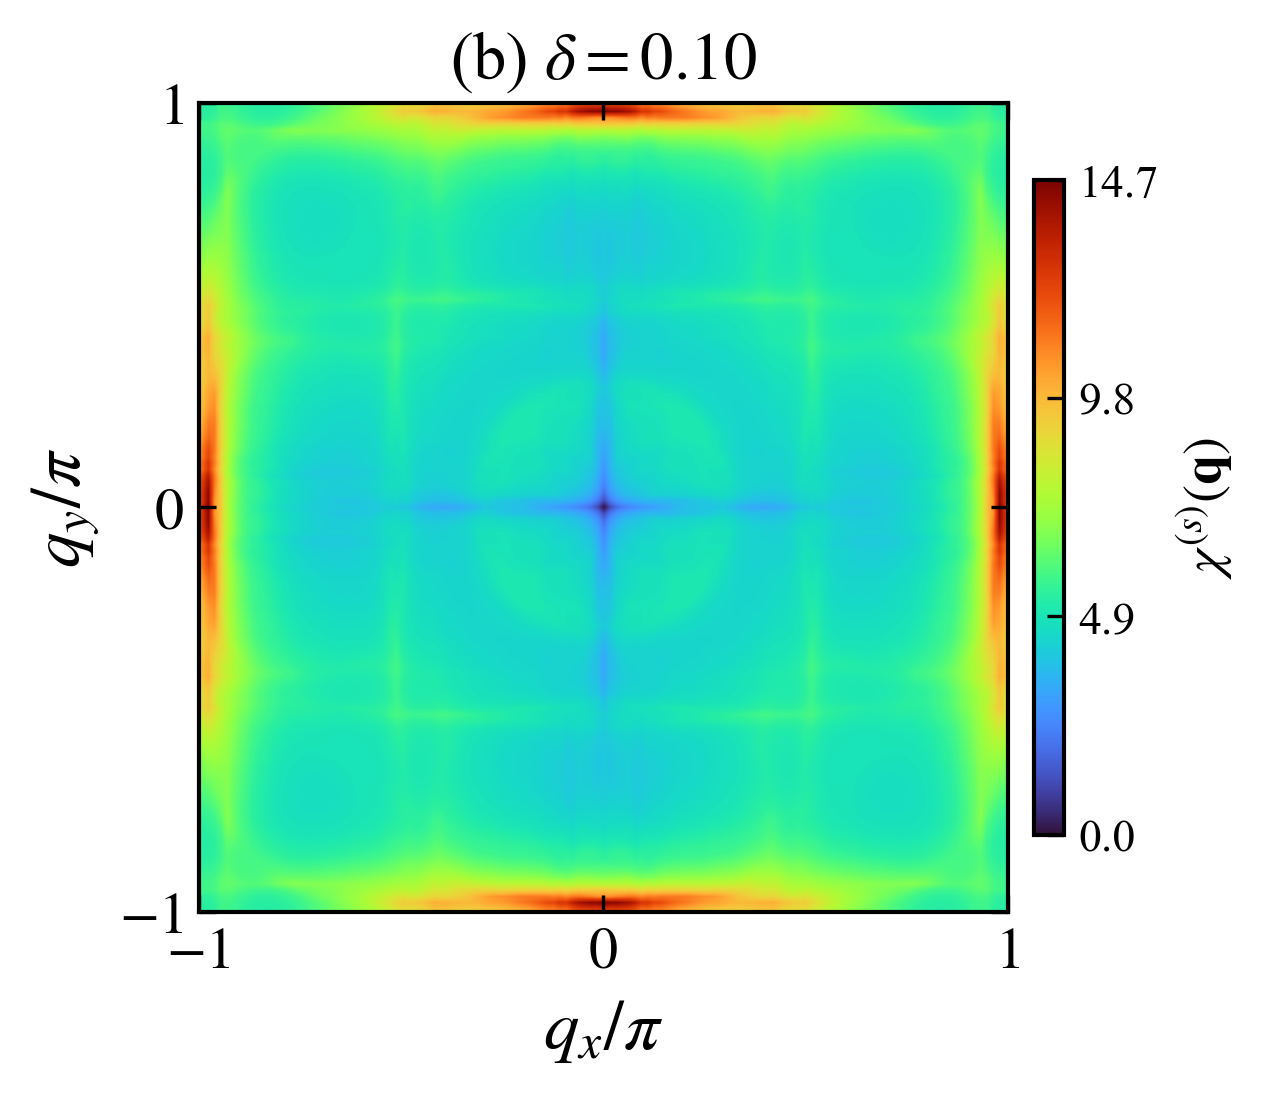

Saved figure: La3Ni2O7_film_Fig4_RPA_chi_julia/figures/fig4_RPA_chis_delta_0p23.png


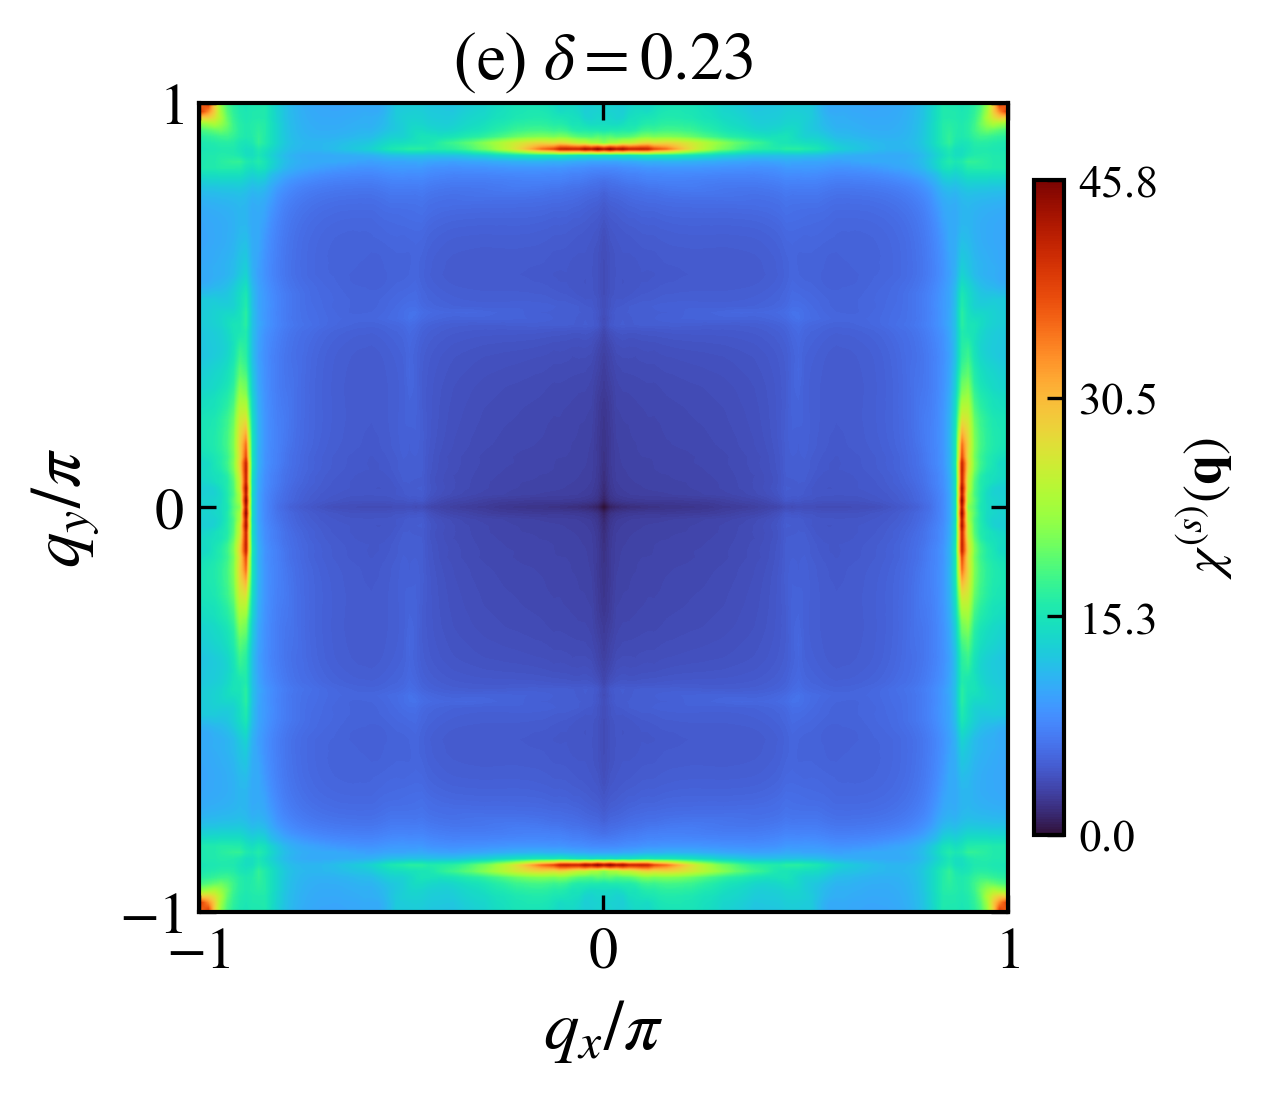

In [ ]:
import os
import glob
from dataclasses import dataclass, field

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# =========================================================
# Config
# =========================================================
@dataclass
class PlotParams:
    dpi: int = 300

    figsize_single: tuple = (4.4, 4.0)
    figsize_combined: tuple = (8.4, 3.8)

    font_size: float = 15
    label_size: float = 17
    tick_size: float = 14
    title_size: float = 16

    cmap: str = "turbo"
    interpolation: str = "bilinear"

    # If True, two dopings use the same color scale.
    use_common_color_scale: bool = False

    vmin: float = 0.0
    vmax: float | None = None

    # colorbar
    n_cbar_ticks: int = 4
    cbar_decimal: int = 1
    cbar_fraction: float = 0.050
    cbar_pad: float = 0.030
    cbar_shrink: float = 0.78
    cbar_aspect: float = 22
    cbar_label_size: float = 13
    cbar_tick_size: float = 11

    show_figures: bool = True

    make_separate_figures: bool = True
    make_combined_figure: bool = True

    fig_dirname: str = "figures"


@dataclass
class Config:
    data_dir: str = "La3Ni2O7_film_Fig4_RPA_chi_julia"

    # If empty, automatically search fig4_chis_delta_*.dat in data_dir.
    data_files: tuple = ()

    plot: PlotParams = field(default_factory=PlotParams)


# =========================================================
# Style
# =========================================================
def set_style(cfg):
    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams["mathtext.fontset"] = "stix"

    plt.rcParams["font.size"] = cfg.plot.font_size
    plt.rcParams["axes.linewidth"] = 1.0

    plt.rcParams["xtick.direction"] = "in"
    plt.rcParams["ytick.direction"] = "in"
    plt.rcParams["xtick.top"] = True
    plt.rcParams["ytick.right"] = True

    plt.rcParams["xtick.major.size"] = 4
    plt.rcParams["ytick.major.size"] = 4


# =========================================================
# Read Julia .dat
# =========================================================
def parse_metadata_from_dat(dat_file):
    metadata = {}

    with open(dat_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line.startswith("#"):
                continue

            text = line[1:].strip()

            if "=" in text:
                key, value = text.split("=", 1)
                key = key.strip()
                value = value.strip()

                metadata[key] = value

    # Convert useful fields to float when possible
    for key in list(metadata.keys()):
        try:
            metadata[key] = float(metadata[key].split()[0])
        except Exception:
            pass

    return metadata


def read_chis_dat(dat_file):
    """
    Read Julia output:

        qx   qy   chis

    Returns:
        qx_values, qy_values, chis_grid, metadata
    """
    metadata = parse_metadata_from_dat(dat_file)

    data = np.loadtxt(dat_file, comments="#")

    if data.ndim == 1:
        data = data.reshape(1, -1)

    if data.shape[1] < 3:
        raise ValueError(f"Data file should have at least 3 columns: {dat_file}")

    qx = data[:, 0]
    qy = data[:, 1]
    chis = data[:, 2]

    qx_values = np.unique(qx)
    qy_values = np.unique(qy)

    qx_values.sort()
    qy_values.sort()

    nx = len(qx_values)
    ny = len(qy_values)

    chis_grid = np.full((ny, nx), np.nan, dtype=float)

    qx_to_ix = {val: i for i, val in enumerate(qx_values)}
    qy_to_iy = {val: i for i, val in enumerate(qy_values)}

    for x, y, z in zip(qx, qy, chis):
        ix = qx_to_ix[x]
        iy = qy_to_iy[y]
        chis_grid[iy, ix] = z

    return {
        "dat_file": dat_file,
        "qx_values": qx_values,
        "qy_values": qy_values,
        "chis": chis_grid,
        "metadata": metadata,
    }


def find_data_files(cfg):
    if len(cfg.data_files) > 0:
        files = [
            f if os.path.isabs(f) else os.path.join(cfg.data_dir, f)
            for f in cfg.data_files
        ]
    else:
        files = sorted(
            glob.glob(
                os.path.join(cfg.data_dir, "fig4_chis_delta_*.dat")
            )
        )

    if len(files) == 0:
        raise FileNotFoundError(
            f"No fig4_chis_delta_*.dat files found in:\n{cfg.data_dir}"
        )

    return files


def load_all_chis_data(cfg):
    files = find_data_files(cfg)

    datasets = []

    for f in files:
        ds = read_chis_dat(f)
        datasets.append(ds)

    datasets.sort(
        key=lambda x: float(x["metadata"].get("delta", 999.0))
    )

    return datasets


# =========================================================
# Plot helpers
# =========================================================
def make_figure_dir(cfg):
    fig_dir = os.path.join(cfg.data_dir, cfg.plot.fig_dirname)
    os.makedirs(fig_dir, exist_ok=True)
    return fig_dir


def format_tick(x, pos, decimal=1):
    threshold = 0.5 * 10 ** (-decimal)

    if abs(x) < threshold:
        x = 0.0

    return f"{x:.{decimal}f}"


def setup_q_axis(ax, cfg):
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)

    ax.set_xticks([-1.0, 0.0, 1.0])
    ax.set_yticks([-1.0, 0.0, 1.0])

    ax.set_xticklabels([r"$-1$", r"$0$", r"$1$"])
    ax.set_yticklabels([r"$-1$", r"$0$", r"$1$"])

    ax.set_xlabel(r"$q_x/\pi$", fontsize=cfg.plot.label_size)
    ax.set_ylabel(r"$q_y/\pi$", fontsize=cfg.plot.label_size)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=cfg.plot.tick_size,
    )

    ax.set_aspect("equal")


def add_colorbar(fig, ax, im, cfg):
    cbar = fig.colorbar(
        im,
        ax=ax,
        pad=cfg.plot.cbar_pad,
        fraction=cfg.plot.cbar_fraction,
        shrink=cfg.plot.cbar_shrink,
        aspect=cfg.plot.cbar_aspect,
    )

    cbar.set_label(
        r"$\chi^{(s)}(\mathbf{q})$",
        fontsize=cfg.plot.cbar_label_size,
    )

    ticks = np.linspace(
        im.norm.vmin,
        im.norm.vmax,
        cfg.plot.n_cbar_ticks,
    )
    cbar.set_ticks(ticks)

    cbar.ax.yaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: format_tick(
                x,
                pos,
                decimal=cfg.plot.cbar_decimal,
            )
        )
    )

    cbar.ax.tick_params(labelsize=cfg.plot.cbar_tick_size)

    return cbar


def get_color_limits(datasets, cfg):
    if cfg.plot.vmax is not None:
        vmax = cfg.plot.vmax
    else:
        vmax = max(np.nanmax(ds["chis"]) for ds in datasets)

    vmin = cfg.plot.vmin

    return vmin, vmax


def get_delta_string(delta):
    return f"{delta:.2f}".replace(".", "p")


def get_panel_label(delta):
    if abs(delta - 0.10) < 1e-6:
        return "(b)"
    if abs(delta - 0.23) < 1e-6:
        return "(e)"
    return ""


# =========================================================
# Plot single map
# =========================================================
def plot_single_dataset(cfg, ds, vmin=None, vmax=None):
    set_style(cfg)

    qx_values = ds["qx_values"]
    qy_values = ds["qy_values"]
    chis = ds["chis"]
    meta = ds["metadata"]

    delta = float(meta.get("delta", np.nan))
    U_used = meta.get("U_used", None)
    mu = meta.get("mu", None)

    if vmin is None:
        vmin = cfg.plot.vmin

    if vmax is None:
        vmax = np.nanmax(chis)

    fig, ax = plt.subplots(
        figsize=cfg.plot.figsize_single,
        dpi=cfg.plot.dpi,
    )

    im = ax.imshow(
        chis,
        origin="lower",
        extent=[
            qx_values[0],
            qx_values[-1],
            qy_values[0],
            qy_values[-1],
        ],
        cmap=cfg.plot.cmap,
        interpolation=cfg.plot.interpolation,
        aspect="equal",
        vmin=vmin,
        vmax=vmax,
    )

    setup_q_axis(ax, cfg)

    panel = get_panel_label(delta)

    if np.isfinite(delta):
        title = rf"{panel} $\delta={delta:.2f}$"
    else:
        title = r"$\chi^{(s)}(\mathbf{q})$"

    ax.set_title(title, fontsize=cfg.plot.title_size)

    add_colorbar(fig, ax, im, cfg)

    fig.tight_layout()

    fig_dir = make_figure_dir(cfg)

    if np.isfinite(delta):
        delta_str = get_delta_string(delta)
        out_name = f"fig4_RPA_chis_delta_{delta_str}.png"
    else:
        base = os.path.splitext(os.path.basename(ds["dat_file"]))[0]
        out_name = f"{base}.png"

    out_png = os.path.join(fig_dir, out_name)

    fig.savefig(out_png, bbox_inches="tight")
    print(f"Saved figure: {out_png}")

    if cfg.plot.show_figures:
        plt.show()

    plt.close(fig)

    return out_png
# =========================================================
# Main plotting
# =========================================================
def run_plotting(cfg):
    datasets = load_all_chis_data(cfg)

    print("=" * 72)
    print("Loaded Julia RPA susceptibility data")
    print("=" * 72)

    for ds in datasets:
        meta = ds["metadata"]
        print(f"File: {ds['dat_file']}")
        print(f"  delta  = {meta.get('delta', 'N/A')}")
        print(f"  mu     = {meta.get('mu', 'N/A')}")
        print(f"  Uc     = {meta.get('Uc', 'N/A')}")
        print(f"  U_used = {meta.get('U_used', 'N/A')}")
        print(f"  chis min/max = {np.nanmin(ds['chis']):.8e}, {np.nanmax(ds['chis']):.8e}")

    print("=" * 72)

    if cfg.plot.use_common_color_scale:
        vmin, vmax = get_color_limits(datasets, cfg)
    else:
        vmin, vmax = None, None

    if cfg.plot.make_separate_figures:
        for ds in datasets:
            plot_single_dataset(cfg, ds, vmin=vmin, vmax=vmax)


# =========================================================
# Build config
# =========================================================
def build_config():
    cfg = Config()

    # Julia output directory
    cfg.data_dir = "La3Ni2O7_film_Fig4_RPA_chi_julia"

    # Leave empty to automatically read:
    # fig4_chis_delta_*.dat
    cfg.data_files = ()

    # If you want to specify files manually:
    # cfg.data_files = (
    #     "fig4_chis_delta_0p10.dat",
    #     "fig4_chis_delta_0p23.dat",
    # )

    cfg.plot.dpi = 300

    cfg.plot.figsize_single = (4.4, 4.0)
    cfg.plot.figsize_combined = (8.4, 3.8)

    cfg.plot.cmap = "turbo"
    cfg.plot.interpolation = "bilinear"

    # Usually False makes each panel's peak clearer.
    # Set True if you want strict comparison between dopings.
    cfg.plot.use_common_color_scale = False

    cfg.plot.vmin = 0.0
    cfg.plot.vmax = None

    cfg.plot.n_cbar_ticks = 4
    cfg.plot.cbar_decimal = 1

    cfg.plot.make_separate_figures = True
    cfg.plot.make_combined_figure = True

    cfg.plot.show_figures = True

    return cfg


# =========================================================
# Run
# =========================================================
cfg = build_config()

run_plotting(cfg)

## 超导

Detected gap topmode files
La3Ni2O7_film_Fig4_full_RPA_gap_mpi/fig4d_gap_delta_0p23_fullRPA_topmodes_rawgap.dat   delta=0.23
Data file: La3Ni2O7_film_Fig4_full_RPA_gap_mpi/fig4d_gap_delta_0p23_fullRPA_topmodes_rawgap.dat
delta = 0.230000
Available gap eigenmodes
mode  1: lambda = 7.703668500188e-02
mode  2: lambda = 3.126007102030e-02
mode  3: lambda = 1.775441967870e-02
mode  4: lambda = 1.126822715405e-02
Gap range summary for gap_raw
mode  1: min = -2.24409501e-01, max =  2.24409501e-01, max| | =  2.24409501e-01
mode  2: min = -2.98142570e-01, max =  2.98142570e-01, max| | =  2.98142570e-01
mode  3: min = -2.75952947e-01, max =  2.75952947e-01, max| | =  2.75952947e-01
mode  4: min = -2.10723664e-01, max =  2.01596486e-01, max| | =  2.10723664e-01
Saved figure: La3Ni2O7_film_Fig4_full_RPA_gap_mpi/figures_topmodes/delta_0p23/gap_raw_on_FS_delta_0p23_mode_01.png


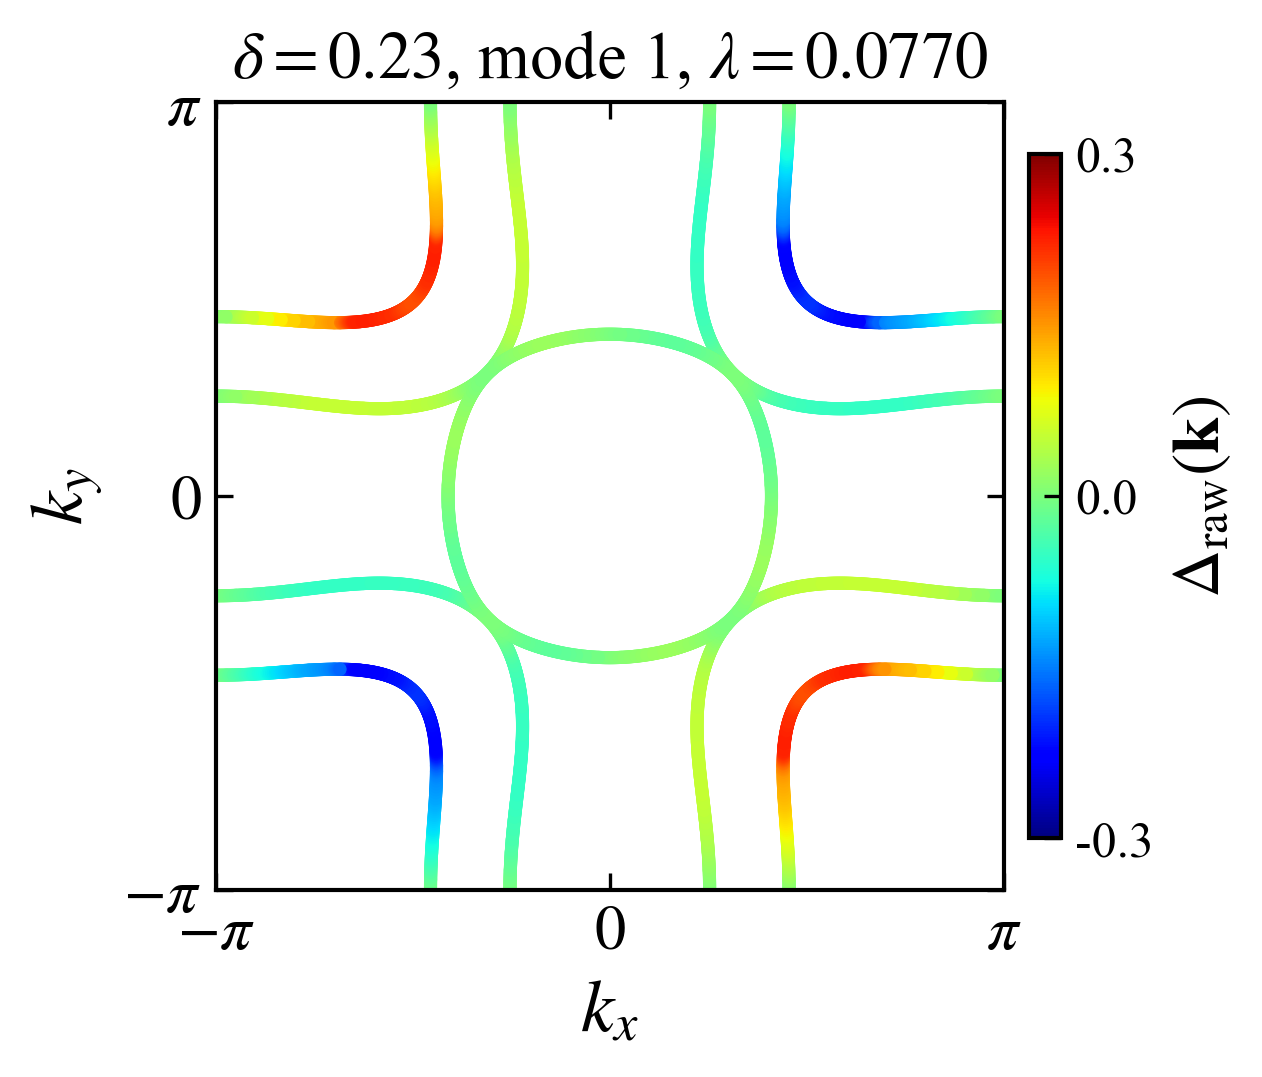

Saved figure: La3Ni2O7_film_Fig4_full_RPA_gap_mpi/figures_topmodes/delta_0p23/gap_raw_on_FS_delta_0p23_mode_02.png


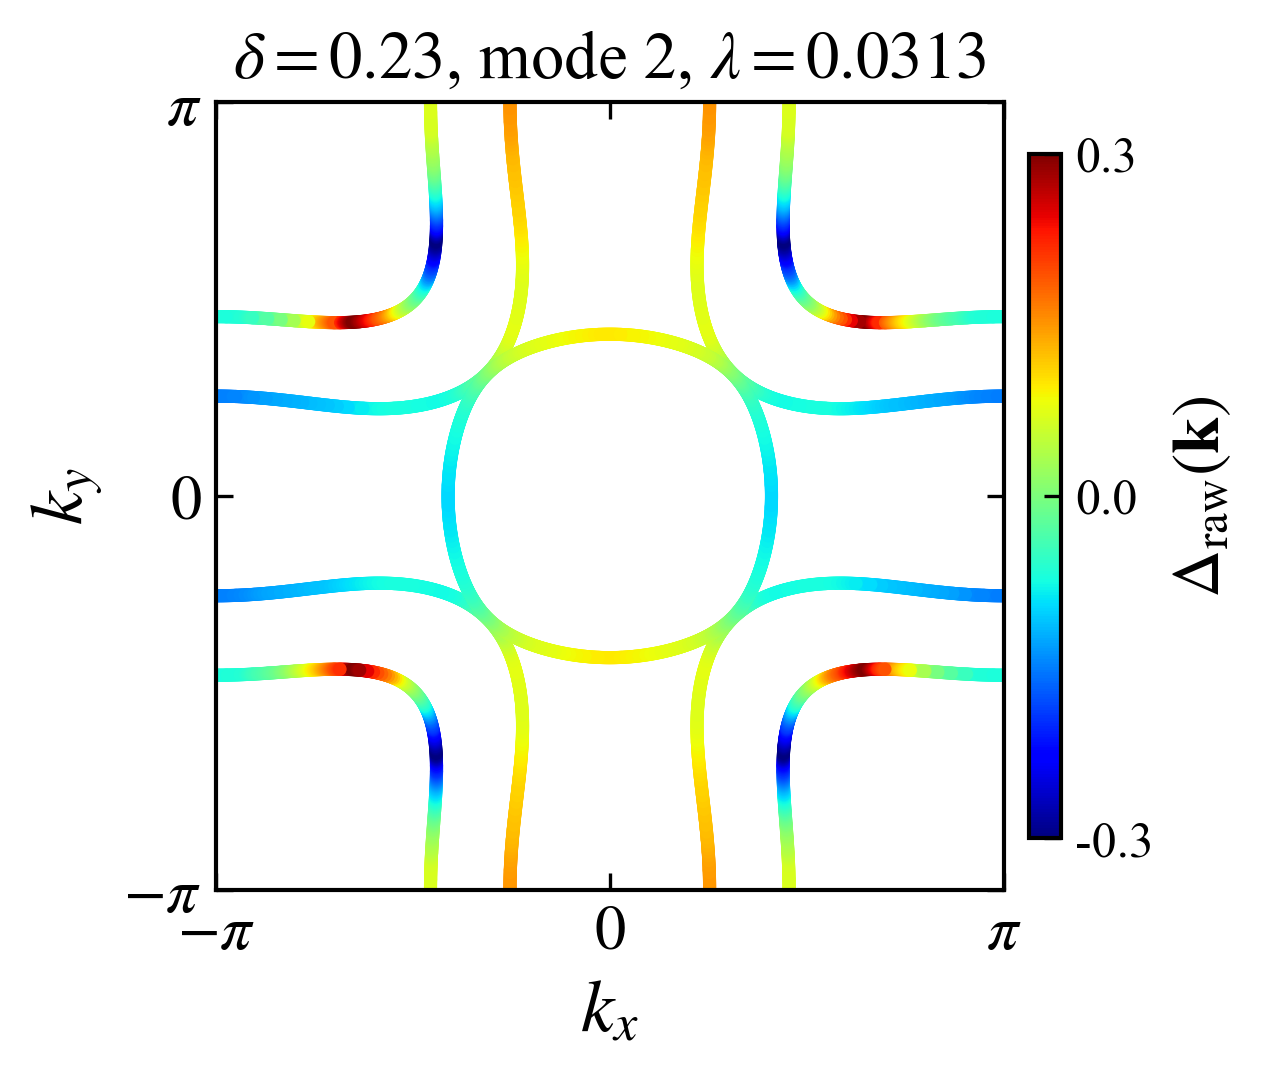

In [ ]:
import os
import re
import glob
from dataclasses import dataclass, field
from typing import Optional, List, Dict, Any

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# =========================================================
# Config
# =========================================================
@dataclass
class PlotConfig:
    data_dir: str = "La3Ni2O7_film_Fig4_full_RPA_gap_mpi"

    # None means auto search.
    data_file: Optional[str] = None

    # Search both new rawgap and old topmodes files.
    file_patterns: List[str] = field(
        default_factory=lambda: [
            "fig4d_gap_delta_*_fullRPA_topmodes_rawgap.dat",
            "fig4d_gap_delta_*_fullRPA_topmodes.dat",
        ]
    )

    # None means plot all detected dopings.
    # Example: delta = 0.23
    delta: Optional[float] = None

    output_dir: Optional[str] = None

    # mode index starts from 1
    selected_modes: List[int] = field(default_factory=lambda: [1, 2, 3, 4])

    # Options:
    #   "gap_norm"     normalized gap, max |Delta| = 1
    #   "gap_raw"      unnormalized gap from phi / sqrt(dl/vF)
    #   "dz2_weight"
    #   "patch_weight"
    #   "vF"
    color_quantity: str = "gap_norm"

    dpi: int = 300
    figsize_single: tuple = (4.4, 4.0)
    figsize_combined: tuple = (8.4, 7.4)

    font_size: float = 15
    label_size: float = 18
    tick_size: float = 15
    title_size: float = 16

    marker_size: float = 10.0
    marker_alpha: float = 1.0
    marker_edge_width: float = 0.0

    cmap: str = "RdBu_r"

    use_symmetric_vlim: bool = True
    use_common_color_scale: bool = True
    use_percentile_vlim: bool = False
    percentile: float = 99.0

    # For gap_norm, fixed [-1,1] is usually best.
    manual_vmin: Optional[float] = -1.0
    manual_vmax: Optional[float] = 1.0

    cbar_fraction: float = 0.055
    cbar_pad: float = 0.030
    cbar_shrink: float = 0.82
    cbar_aspect: float = 22
    cbar_tick_size: float = 12
    cbar_label_size: float = 16
    cbar_decimal: int = 1

    axis_limit: float = 1.0
    show_title: bool = True

    make_single_figures: bool = True
    make_combined_figure: bool = True
    save_png: bool = True
    show_figure: bool = True


# =========================================================
# Style
# =========================================================
def set_style(cfg: PlotConfig):
    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams["mathtext.fontset"] = "stix"

    plt.rcParams["font.size"] = cfg.font_size
    plt.rcParams["axes.linewidth"] = 1.0

    plt.rcParams["xtick.direction"] = "in"
    plt.rcParams["ytick.direction"] = "in"
    plt.rcParams["xtick.top"] = True
    plt.rcParams["ytick.right"] = True

    plt.rcParams["xtick.major.size"] = 4
    plt.rcParams["ytick.major.size"] = 4


# =========================================================
# Metadata and file detection
# =========================================================
def parse_metadata(dat_file: str) -> Dict[str, Any]:
    metadata: Dict[str, Any] = {}

    with open(dat_file, "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()

            if not s.startswith("#"):
                continue

            s = s[1:].strip()

            if "=" not in s:
                continue

            key, value = s.split("=", 1)
            key = key.strip()
            value = value.strip()

            try:
                metadata[key] = float(value.split()[0])
            except Exception:
                metadata[key] = value

    return metadata


def infer_delta_from_filename(filename: str) -> Optional[float]:
    base = os.path.basename(filename)

    m = re.search(r"delta_([0-9]+(?:p|\.)[0-9]+)", base)

    if m is None:
        return None

    token = m.group(1).replace("p", ".")

    try:
        return float(token)
    except Exception:
        return None


def get_delta_from_file(dat_file: str) -> Optional[float]:
    meta = parse_metadata(dat_file)

    if "delta" in meta:
        try:
            return float(meta["delta"])
        except Exception:
            pass

    return infer_delta_from_filename(dat_file)


def delta_to_string(delta: Optional[float]) -> str:
    if delta is None or not np.isfinite(delta):
        return "unknown"

    return f"{delta:.2f}".replace(".", "p")


def find_gap_files(cfg: PlotConfig) -> List[str]:
    if cfg.data_file is not None:
        if not os.path.exists(cfg.data_file):
            raise FileNotFoundError(f"Cannot find data file:\n{cfg.data_file}")
        return [cfg.data_file]

    files = []

    for pattern in cfg.file_patterns:
        files.extend(glob.glob(os.path.join(cfg.data_dir, pattern)))

    files = sorted(set(f for f in files if os.path.isfile(f)))

    # Prefer rawgap files over old files when both exist for the same delta.
    by_delta: Dict[str, str] = {}

    for f in files:
        d = get_delta_from_file(f)
        dstr = delta_to_string(d)

        old = by_delta.get(dstr, None)

        if old is None:
            by_delta[dstr] = f
        else:
            f_is_raw = "rawgap" in os.path.basename(f)
            old_is_raw = "rawgap" in os.path.basename(old)

            if f_is_raw and not old_is_raw:
                by_delta[dstr] = f

    files = sorted(by_delta.values())

    if len(files) == 0:
        raise FileNotFoundError(
            "No gap topmode data files found.\n"
            f"Search directory:\n{cfg.data_dir}\n\n"
            "Expected names like:\n"
            "  fig4d_gap_delta_0p23_fullRPA_topmodes_rawgap.dat\n"
            "  fig4d_gap_delta_0p23_fullRPA_topmodes.dat"
        )

    if cfg.delta is None:
        return files

    selected = []

    for f in files:
        d = get_delta_from_file(f)
        if d is not None and abs(d - cfg.delta) < 5e-4:
            selected.append(f)

    if len(selected) == 0:
        info = []
        for f in files:
            info.append(f"{os.path.basename(f)}   delta={get_delta_from_file(f)}")

        raise FileNotFoundError(
            f"No file found for delta={cfg.delta}.\n\n"
            "Available files:\n" + "\n".join(info)
        )

    return selected


# =========================================================
# Read gap data
# =========================================================
def read_gap_topmode_data(dat_file: str) -> Dict[str, Any]:
    """
    New combined file format:

        mode lambda kx/pi ky/pi band gap_raw gap_norm dz2_weight patch_weight vF

    New single-mode file format:

        kx/pi ky/pi band gap_raw gap_norm dz2_weight patch_weight vF

    Old files with columns named gap/gap_norm are also readable.
    In old files, the first gap column is treated as gap_raw.
    """
    if not os.path.exists(dat_file):
        raise FileNotFoundError(f"Cannot find data file:\n{dat_file}")

    metadata = parse_metadata(dat_file)
    raw = np.loadtxt(dat_file, comments="#")

    if raw.ndim == 1:
        raw = raw.reshape(1, -1)

    if raw.shape[1] == 10:
        data = {
            "mode": raw[:, 0].astype(int),
            "lambda": raw[:, 1],
            "kx": raw[:, 2],
            "ky": raw[:, 3],
            "band": raw[:, 4].astype(int),
            "gap_raw": raw[:, 5],
            "gap_norm": raw[:, 6],
            "dz2_weight": raw[:, 7],
            "patch_weight": raw[:, 8],
            "vF": raw[:, 9],
            "metadata": metadata,
            "data_file": dat_file,
        }

    elif raw.shape[1] == 8:
        mode = int(metadata.get("mode", 1))
        lam = float(metadata.get("lambda", np.nan))
        n = raw.shape[0]

        data = {
            "mode": np.full(n, mode, dtype=int),
            "lambda": np.full(n, lam, dtype=float),
            "kx": raw[:, 0],
            "ky": raw[:, 1],
            "band": raw[:, 2].astype(int),
            "gap_raw": raw[:, 3],
            "gap_norm": raw[:, 4],
            "dz2_weight": raw[:, 5],
            "patch_weight": raw[:, 6],
            "vF": raw[:, 7],
            "metadata": metadata,
            "data_file": dat_file,
        }

    else:
        raise ValueError(
            f"Unsupported data format in {dat_file}.\n"
            "Expected 10 columns for combined topmode file or 8 columns for single-mode file."
        )

    # Backward-compatible alias.
    data["gap"] = data["gap_raw"]

    delta = None

    if "delta" in metadata:
        try:
            delta = float(metadata["delta"])
        except Exception:
            pass

    if delta is None:
        delta = infer_delta_from_filename(dat_file)

    data["delta"] = delta

    return data


# =========================================================
# Helper functions
# =========================================================
def get_modes_available(data: Dict[str, Any]) -> List[int]:
    return sorted(np.unique(data["mode"]).astype(int))


def get_mode_lambda(data: Dict[str, Any], mode: int) -> float:
    mask = data["mode"] == mode

    if not np.any(mask):
        return np.nan

    vals = data["lambda"][mask]
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return np.nan

    return float(vals[0])


def get_color_values(data: Dict[str, Any], cfg: PlotConfig):
    if cfg.color_quantity not in data:
        raise ValueError(
            f"Unknown color_quantity: {cfg.color_quantity}\n"
            "Available options: gap_raw, gap_norm, gap, dz2_weight, patch_weight, vF"
        )

    return data[cfg.color_quantity]


def get_colorbar_label(cfg: PlotConfig) -> str:
    if cfg.color_quantity == "gap_raw":
        return r"$\Delta_{\rm raw}(\mathbf{k})$"

    if cfg.color_quantity in ["gap_norm", "gap"]:
        return r"$\Delta_{\rm norm}(\mathbf{k})$"

    if cfg.color_quantity == "dz2_weight":
        return r"$d_{z^2}$ weight"

    if cfg.color_quantity == "patch_weight":
        return r"$\Delta l/v_F$"

    if cfg.color_quantity == "vF":
        return r"$v_F$"

    return cfg.color_quantity


def get_color_limits(values, cfg: PlotConfig):
    values = np.asarray(values)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        raise ValueError("No finite values for color scale.")

    if cfg.manual_vmin is not None and cfg.manual_vmax is not None:
        return cfg.manual_vmin, cfg.manual_vmax

    if cfg.color_quantity == "dz2_weight":
        return 0.0, 1.0

    if cfg.use_percentile_vlim:
        vmax = np.percentile(np.abs(values), cfg.percentile)
    else:
        vmax = np.max(np.abs(values))

    if cfg.manual_vmax is not None:
        vmax = cfg.manual_vmax

    if cfg.use_symmetric_vlim:
        vmin = -vmax
    else:
        vmin = np.min(values)

    if cfg.manual_vmin is not None:
        vmin = cfg.manual_vmin

    return vmin, vmax


def setup_k_axis(ax, cfg: PlotConfig):
    lim = cfg.axis_limit

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")

    ax.set_xticks([-1.0, 0.0, 1.0])
    ax.set_yticks([-1.0, 0.0, 1.0])

    ax.set_xticklabels([r"$-\pi$", r"$0$", r"$\pi$"])
    ax.set_yticklabels([r"$-\pi$", r"$0$", r"$\pi$"])

    ax.set_xlabel(r"$k_x$", fontsize=cfg.label_size)
    ax.set_ylabel(r"$k_y$", fontsize=cfg.label_size)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=cfg.tick_size,
    )


def format_cbar_tick(x, pos, decimal=1):
    if abs(x) < 0.5 * 10 ** (-decimal):
        x = 0.0

    return f"{x:.{decimal}f}"


def add_colorbar(fig, ax, sc, cfg: PlotConfig, vmin, vmax):
    cbar = fig.colorbar(
        sc,
        ax=ax,
        pad=cfg.cbar_pad,
        fraction=cfg.cbar_fraction,
        shrink=cfg.cbar_shrink,
        aspect=cfg.cbar_aspect,
    )

    cbar.set_label(
        get_colorbar_label(cfg),
        fontsize=cfg.cbar_label_size,
    )

    if vmin < 0.0 < vmax:
        cbar.set_ticks([vmin, 0.0, vmax])
    else:
        cbar.set_ticks([vmin, vmax])

    cbar.ax.yaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: format_cbar_tick(
                x,
                pos,
                decimal=cfg.cbar_decimal,
            )
        )
    )

    cbar.ax.tick_params(labelsize=cfg.cbar_tick_size)

    return cbar


def make_output_dir_for_data(cfg: PlotConfig, data: Dict[str, Any]) -> str:
    if cfg.output_dir is not None:
        base_dir = cfg.output_dir
    else:
        base_dir = os.path.join(
            os.path.dirname(data["data_file"]),
            "figures_topmodes",
        )

    delta_str = delta_to_string(data.get("delta", None))
    out_dir = os.path.join(base_dir, f"delta_{delta_str}")
    os.makedirs(out_dir, exist_ok=True)

    return out_dir


def build_title(data: Dict[str, Any], mode: int, cfg: PlotConfig) -> str:
    delta = data.get("delta", None)
    lam = get_mode_lambda(data, mode)

    if delta is None:
        return rf"mode {mode}, $\lambda={lam:.4f}$"

    return rf"$\delta={delta:.2f}$, mode {mode}, $\lambda={lam:.4f}$"


# =========================================================
# Single mode plot
# =========================================================
def plot_single_mode(
    data: Dict[str, Any],
    cfg: PlotConfig,
    mode: int,
    output_dir: str,
    vmin=None,
    vmax=None,
):
    set_style(cfg)

    mask = data["mode"] == mode

    if not np.any(mask):
        print(f"Warning: mode {mode} not found. Skip.")
        return None

    kx = data["kx"][mask]
    ky = data["ky"][mask]
    band = data["band"][mask]
    values = get_color_values(data, cfg)[mask]

    if vmin is None or vmax is None:
        vmin, vmax = get_color_limits(values, cfg)

    fig, ax = plt.subplots(
        figsize=cfg.figsize_single,
        dpi=cfg.dpi,
    )

    sc = None

    for ib in sorted(np.unique(band)):
        bmask = band == ib

        sc = ax.scatter(
            kx[bmask],
            ky[bmask],
            c=values[bmask],
            s=cfg.marker_size,
            cmap=cfg.cmap,
            vmin=vmin,
            vmax=vmax,
            alpha=cfg.marker_alpha,
            linewidths=cfg.marker_edge_width,
            edgecolors="none",
            rasterized=True,
        )

    setup_k_axis(ax, cfg)

    if cfg.show_title:
        ax.set_title(build_title(data, mode, cfg), fontsize=cfg.title_size)

    add_colorbar(fig, ax, sc, cfg, vmin, vmax)

    fig.tight_layout()

    delta_str = delta_to_string(data.get("delta", None))
    quantity = cfg.color_quantity

    out_png = os.path.join(
        output_dir,
        f"{quantity}_on_FS_delta_{delta_str}_mode_{mode:02d}.png",
    )

    if cfg.save_png:
        fig.savefig(out_png, bbox_inches="tight")
        print(f"Saved figure: {out_png}")

    if cfg.show_figure:
        plt.show()

    plt.close(fig)

    return out_png


# =========================================================
# Combined mode plot
# =========================================================
def plot_combined_modes(
    data: Dict[str, Any],
    cfg: PlotConfig,
    output_dir: str,
):
    set_style(cfg)

    selected_modes = [
        m for m in cfg.selected_modes
        if m in get_modes_available(data)
    ]

    if len(selected_modes) == 0:
        print("Warning: no selected modes found in data. Skip combined plot.")
        return None

    nmode = len(selected_modes)
    ncol = 2 if nmode > 1 else 1
    nrow = int(np.ceil(nmode / ncol))

    fig, axes = plt.subplots(
        nrow,
        ncol,
        figsize=cfg.figsize_combined,
        dpi=cfg.dpi,
        constrained_layout=True,
    )

    axes = np.array(axes).reshape(-1)

    if cfg.use_common_color_scale:
        all_values = []

        for mode in selected_modes:
            mask = data["mode"] == mode
            all_values.append(get_color_values(data, cfg)[mask])

        all_values = np.concatenate(all_values)
        common_vmin, common_vmax = get_color_limits(all_values, cfg)
    else:
        common_vmin, common_vmax = None, None

    last_sc = None

    for iax, mode in enumerate(selected_modes):
        ax = axes[iax]
        mask = data["mode"] == mode

        kx = data["kx"][mask]
        ky = data["ky"][mask]
        band = data["band"][mask]
        values = get_color_values(data, cfg)[mask]

        if cfg.use_common_color_scale:
            vmin, vmax = common_vmin, common_vmax
        else:
            vmin, vmax = get_color_limits(values, cfg)

        for ib in sorted(np.unique(band)):
            bmask = band == ib

            last_sc = ax.scatter(
                kx[bmask],
                ky[bmask],
                c=values[bmask],
                s=cfg.marker_size,
                cmap=cfg.cmap,
                vmin=vmin,
                vmax=vmax,
                alpha=cfg.marker_alpha,
                linewidths=cfg.marker_edge_width,
                edgecolors="none",
                rasterized=True,
            )

        setup_k_axis(ax, cfg)

        if cfg.show_title:
            ax.set_title(build_title(data, mode, cfg), fontsize=cfg.title_size)

        if not cfg.use_common_color_scale:
            add_colorbar(fig, ax, last_sc, cfg, vmin, vmax)

    for j in range(nmode, len(axes)):
        axes[j].axis("off")

    if cfg.use_common_color_scale:
        cbar = fig.colorbar(
            last_sc,
            ax=axes[:nmode],
            pad=0.025,
            fraction=0.02,
            shrink=0.82,
            aspect=24,
        )

        cbar.set_label(get_colorbar_label(cfg), fontsize=cfg.cbar_label_size)

        if common_vmin < 0.0 < common_vmax:
            cbar.set_ticks([common_vmin, 0.0, common_vmax])
        else:
            cbar.set_ticks([common_vmin, common_vmax])

        cbar.ax.yaxis.set_major_formatter(
            FuncFormatter(
                lambda x, pos: format_cbar_tick(
                    x,
                    pos,
                    decimal=cfg.cbar_decimal,
                )
            )
        )
        cbar.ax.tick_params(labelsize=cfg.cbar_tick_size)

    delta_str = delta_to_string(data.get("delta", None))
    quantity = cfg.color_quantity

    out_png = os.path.join(
        output_dir,
        f"{quantity}_on_FS_delta_{delta_str}_selected_topmodes.png",
    )

    if cfg.save_png:
        fig.savefig(out_png, bbox_inches="tight")
        print(f"Saved figure: {out_png}")

    if cfg.show_figure:
        plt.show()

    plt.close(fig)

    return out_png


# =========================================================
# Summary
# =========================================================
def print_eigenvalue_summary(data: Dict[str, Any]):
    modes = get_modes_available(data)
    delta = data.get("delta", None)

    print("=" * 72)
    print(f"Data file: {data['data_file']}")
    if delta is not None:
        print(f"delta = {delta:.6f}")
    print("Available gap eigenmodes")
    print("=" * 72)

    for mode in modes:
        lam = get_mode_lambda(data, mode)
        print(f"mode {mode:2d}: lambda = {lam:.12e}")

    print("=" * 72)


def print_gap_range_summary(data: Dict[str, Any], cfg: PlotConfig):
    modes = get_modes_available(data)
    quantity = cfg.color_quantity

    print("=" * 72)
    print(f"Gap range summary for {quantity}")
    print("=" * 72)

    for mode in modes:
        mask = data["mode"] == mode
        values = get_color_values(data, cfg)[mask]

        print(
            f"mode {mode:2d}: "
            f"min = {np.nanmin(values): .8e}, "
            f"max = {np.nanmax(values): .8e}, "
            f"max| | = {np.nanmax(np.abs(values)): .8e}"
        )

    print("=" * 72)


# =========================================================
# Main workflow
# =========================================================
def run_plotting(cfg: PlotConfig):
    files = find_gap_files(cfg)

    print("=" * 72)
    print("Detected gap topmode files")
    print("=" * 72)
    for f in files:
        print(f"{f}   delta={get_delta_from_file(f)}")
    print("=" * 72)

    for dat_file in files:
        data = read_gap_topmode_data(dat_file)
        output_dir = make_output_dir_for_data(cfg, data)

        print_eigenvalue_summary(data)
        print_gap_range_summary(data, cfg)

        if cfg.use_common_color_scale:
            selected_values = []

            for mode in cfg.selected_modes:
                mask = data["mode"] == mode
                if np.any(mask):
                    selected_values.append(get_color_values(data, cfg)[mask])

            if len(selected_values) > 0:
                selected_values = np.concatenate(selected_values)
                common_vmin, common_vmax = get_color_limits(selected_values, cfg)
            else:
                common_vmin, common_vmax = None, None
        else:
            common_vmin, common_vmax = None, None

        if cfg.make_single_figures:
            for mode in cfg.selected_modes:
                plot_single_mode(
                    data,
                    cfg,
                    mode,
                    output_dir=output_dir,
                    vmin=common_vmin,
                    vmax=common_vmax,
                )

        if cfg.make_combined_figure:
            plot_combined_modes(
                data,
                cfg,
                output_dir=output_dir,
            )


# =========================================================
# Build config
# =========================================================
def build_config():
    cfg = PlotConfig()

    cfg.data_dir = "La3Ni2O7_film_Fig4_full_RPA_gap_mpi"
    cfg.data_file = None

    # None means plot all detected dopings.
    # Set cfg.delta = 0.23 to plot only delta=0.23.
    cfg.delta = None

    cfg.selected_modes = [1, 2]

    # Default: plot normalized gap.
    cfg.color_quantity = "gap_norm"
    cfg.manual_vmin = -1.0
    cfg.manual_vmax = 1.0
    cfg.use_symmetric_vlim = True
    cfg.use_common_color_scale = True
    cfg.cmap = "jet"

    # To inspect raw unnormalized gap, use:
    cfg.color_quantity = "gap_raw"
    cfg.manual_vmin = None
    cfg.manual_vmax = None
    # cfg.use_symmetric_vlim = True
    # cfg.use_common_color_scale = True
    # cfg.use_percentile_vlim = True
    # cfg.percentile = 99.0

    # To inspect orbital character:
    # cfg.color_quantity = "dz2_weight"
    # cfg.manual_vmin = 0.0
    # cfg.manual_vmax = 1.0
    # cfg.use_symmetric_vlim = False
    # cfg.cmap = "coolwarm"

    cfg.dpi = 300
    cfg.figsize_single = (4.4, 4.0)
    cfg.figsize_combined = (8.4, 7.4)

    cfg.marker_size = 10.0
    cfg.marker_alpha = 1.0

    cfg.make_single_figures = True
    cfg.make_combined_figure = True

    cfg.show_figure = True
    cfg.save_png = True

    return cfg


# =========================================================
# Run
# =========================================================
cfg = build_config() 
run_plotting(cfg)